# Observed DNF Model

**Hierarchical Bayesian Model for Ultrarunning Pace with Selection Bias Quantification**

This notebook implements a sophisticated two-stage hierarchical Bayesian model to estimate ultrarunning race performance while **directly quantifying selection bias** from DNFs (Did Not Finish). The model uses correlated course effects to learn the relationship between course difficulty and DNF rates, enabling inference about unobserved finish times for runners who DNF'd.

## Model Architecture

**Gender-Specific Power Law + Correlated Course Effects:**
- **Finish Time Model**: `pace[gender] ~ distance^β[gender] × course_difficulty`
- **DNF Model**: `P(DNF | course, distance)` with course-specific intercepts
- **Key Innovation**: LKJ correlation prior jointly models finish time and DNF effects
  - **Positive correlation** → harder courses cause more DNFs → observed times underestimate population mean
  - **Correlation magnitude** directly quantifies selection bias severity

## Two-Stage Estimation Strategy

**Stage 1: K-Core MCMC (High-Quality Hyperparameters)**
- **K-core subset** (alpha, beta parameters): Densely-connected runners + courses
- **Full Bayesian inference**: MCMC sampling for hyperparameters + course effects
- **Purpose**: Obtain reliable estimates of population-level parameters

**Stage 2: MAP Extension (Full Dataset)**
- **Fixed hyperparameters** from K-core posterior medians
- **Estimate only**: Course-specific effects for all courses (including sparse ones)
- **Purpose**: Extend predictions to full dataset efficiently

## Data Structure

**Finish Time Observations** (n_finishers):
- **Coordinates**: `gender` (M/F), `course` (race name + distance), `log_distance_ratio`
- **Outcome**: `time` (observed finish time in seconds)
- **Likelihood**: LogNormal with **fixed noise** (σ=0.15) to prevent unrealistic heavy tails

**DNF Observations** (n_results):
- **Coordinates**: `course`, `log_distance_ratio`
- **Outcome**: `did_finish` (binary: 1=finished, 0=DNF)
- **Likelihood**: Bernoulli(logit_p)
- **Note**: DNF model **pools across genders** (assumes equal DNF rates M/F)

## Model Parameters

**Population-Level Hyperparameters:**
- `pace_marathon[gender]`: Baseline pace at marathon distance (gender-specific)
- `pace_distance_effect[gender]`: Power law exponent (how pace degrades with distance)
- `dnf_rate_marathon`: Baseline DNF probability at marathon distance (logit scale)
- `dnf_distance_multiplier`: How DNF probability scales with log(distance)

**Correlated Course Effects** (n_courses × 2):
- `course_effects[:, 0]`: Finish time multiplier (shared across genders)
- `course_effects[:, 1]`: DNF probability multiplier
- `course_correlation`: **THE KEY PARAMETER** - quantifies selection bias
  - Positive correlation → selection bias present
  - Magnitude → severity of bias

**Non-Centered Parameterization:**
```python
course_effects_raw ~ Normal(0, 1)
chol ~ LKJCholeskyCov(n=2, eta=2, sd_dist=course_effect_sds)
course_effects = course_effects_raw @ chol  # Correlated effects
```

## Key Design Decisions

1. **Fixed Observation Noise (σ=0.15)**: Prevents unrealistic heavy tails in LogNormal likelihood
2. **Gender-Pooled DNF Model**: Assumes M/F have equal DNF rates (could be relaxed)
3. **Shared Course Difficulty**: Course effects identical for M/F (could allow gender-specific)
4. **Strong Regularization**: Prior widths tightened 10× to prevent unrealistic predictions
5. **DNF Filtering**: Only includes courses with ≥1 observed DNF to avoid non-reporting bias

## Model Output

**Primary Inference Target:**
- **Selection Bias Estimate**: `expected_bias_pct ≈ median_dnf_rate × median_correlation`
  - Quantifies how much observed finish times underestimate population mean
  - Direct measurement of survivorship bias in ultrarunning performance data

**Secondary Outputs:**
- Gender-specific pace predictions across distances
- Course-specific difficulty rankings
- Posterior predictive distributions for counterfactual scenarios

## Setup

Load and process the whole dataset

In [1]:
import os
import platform
import multiprocessing

# CRITICAL: Set JAX environment variables BEFORE any imports that might load JAX
os.environ['MallocStackLogging'] = '0'

IS_MACOS = platform.system() == 'Darwin'
IS_LINUX = platform.system() == 'Linux'
N_CPUS = multiprocessing.cpu_count()

if IS_MACOS:
    # macOS: Force CPU-only to avoid Metal backend issues
    os.environ['JAX_PLATFORMS'] = 'cpu'
    os.environ['XLA_FLAGS'] = '--xla_force_host_platform_device_count=4'
    os.environ['OMP_NUM_THREADS'] = '1'
    os.environ['MKL_NUM_THREADS'] = '1'
elif IS_LINUX:
    # Linux: Enable GPU if available, otherwise optimize CPU
    os.environ['OMP_NUM_THREADS'] = str(max(1, N_CPUS // 4))
    os.environ['MKL_NUM_THREADS'] = str(max(1, N_CPUS // 4))

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

import sys
import pickle
from pathlib import Path
import time

import jax
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import matplotlib.pyplot as plt
import seaborn as sns

# Configure matplotlib
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Our utilities
sys.path.insert(0, os.path.join(os.getcwd(), 'utils'))

from data_processing import load_results, process_results, filter_races_with_dnfs
from kcore_subsetting import subset_kcore_data
from mcmc_notifications import notify_mcmc_start, notify_mcmc_complete, notify_mcmc_error, build_mcmc_summary_string
from empirical_priors import (
    calculate_gender_marathon_pace,
    calculate_gender_distance_exponent,
    calculate_course_variation,
    calculate_dnf_priors
)
from utils import plot_posterior_diagnostics

# Detect GPU and configure sampler (after JAX import)
GPU_DEVICES = [d for d in jax.devices() if d.platform == 'gpu']
HAS_GPU = len(GPU_DEVICES) > 0
JAX_BACKEND = jax.default_backend()
JAX_DEVICE_COUNT = jax.local_device_count()  # Number of devices available for parallel chains

if IS_MACOS:
    # macOS: Use blackjax for better CPU compatibility
    NUTS_SAMPLER = 'blackjax'
    N_CHAINS = 4
    N_CORES = 4
    PLATFORM_CONFIG = f"macOS (CPU + blackjax, {JAX_DEVICE_COUNT} devices)"
elif IS_LINUX and HAS_GPU:
    # Linux with GPU: Use numpyro for CUDA optimization
    NUTS_SAMPLER = 'numpyro'
    N_CHAINS = 4
    N_CORES = 4
    PLATFORM_CONFIG = f"Linux + GPU (numpyro, {len(GPU_DEVICES)} GPU(s), {JAX_DEVICE_COUNT} JAX device(s))"
else:
    # Linux CPU-only: Use numpyro with CPU chains
    NUTS_SAMPLER = 'numpyro'
    N_CHAINS = min(4, N_CPUS)
    N_CORES = N_CHAINS
    PLATFORM_CONFIG = f"Linux CPU (numpyro, {JAX_DEVICE_COUNT} devices)"

print(f"✅ Platform configuration: {PLATFORM_CONFIG}")
print(f"   JAX backend: {JAX_BACKEND}")
print(f"   JAX device count: {JAX_DEVICE_COUNT}")
print(f"   Sampler: {NUTS_SAMPLER}, Chains: {N_CHAINS}, Cores: {N_CORES}")
if JAX_DEVICE_COUNT < N_CHAINS:
    print(f"   ⚠️  Note: {N_CHAINS} chains will run sequentially on {JAX_DEVICE_COUNT} device(s)")

✅ Platform configuration: Linux + GPU (numpyro, 4 GPU(s), 4 JAX device(s))
   JAX backend: gpu
   JAX device count: 4
   Sampler: numpyro, Chains: 4, Cores: 4


W1125 01:16:16.605185    4528 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W1125 01:16:16.605575    4526 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W1125 01:16:16.605684    4525 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W1125 01:16:16.605868    4527 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W1125 01:16:16.610174    4114 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W1125 01:16:16.610548    4114 cuda_executor.cc:1802] GPU int

In [2]:

# Print hardware information
print("=" * 80)
print("HARDWARE INFORMATION")
print("=" * 80)

# Platform info
print(f"Platform: {platform.platform()}")
print(f"Processor: {platform.processor()}")
print(f"Python: {platform.python_version()}")

# CPU info
cpu_count = multiprocessing.cpu_count()
print(f"\nCPU Cores: {cpu_count}")

# JAX CPU configuration
jax_cpu_devices = [d for d in jax.devices() if d.platform == 'cpu']
print(f"JAX CPU Devices: {len(jax_cpu_devices)}")
xla_flags = os.environ.get('XLA_FLAGS', 'Not set')
print(f"XLA_FLAGS: {xla_flags}")

# PyTensor/OpenMP threading
omp_threads = os.environ.get('OMP_NUM_THREADS', 'Not set')
mkl_threads = os.environ.get('MKL_NUM_THREADS', 'Not set')
print(f"OMP_NUM_THREADS: {omp_threads}")
print(f"MKL_NUM_THREADS: {mkl_threads}")

# GPU info
print(f"\nJAX Backend: {jax.default_backend()}")
print(f"JAX Device Count: {jax.local_device_count()} (available for parallel chains)")
gpu_devices = [d for d in jax.devices() if d.platform == 'gpu']
if gpu_devices:
    print(f"GPU Available: YES - {len(gpu_devices)} device(s)")
    for i, device in enumerate(gpu_devices):
        print(f"  GPU {i}: {device.device_kind}")
    # Try to get CUDA version
    try:
        import jax.lib
        if hasattr(jax.lib, 'xla_bridge'):
            cuda_version = jax.lib.xla_bridge.get_backend().platform_version
            print(f"  CUDA Version: {cuda_version}")
    except:
        pass
else:
    print(f"GPU Available: NO (using CPU)")

# Package versions
print(f"\nPackage Versions:")
print(f"  NumPy: {np.__version__}")
print(f"  JAX: {jax.__version__}")
print(f"  PyMC: {pm.__version__}")
print(f"  ArviZ: {az.__version__}")

HARDWARE INFORMATION
Platform: Linux-6.8.0-45-generic-x86_64-with-glibc2.35
Processor: x86_64
Python: 3.12.12

CPU Cores: 128
JAX CPU Devices: 0
XLA_FLAGS: Not set
OMP_NUM_THREADS: 32
MKL_NUM_THREADS: 32

JAX Backend: gpu
JAX Device Count: 4 (available for parallel chains)
GPU Available: YES - 4 device(s)
  GPU 0: NVIDIA GeForce RTX 4090
  GPU 1: NVIDIA GeForce RTX 4090
  GPU 2: NVIDIA GeForce RTX 4090
  GPU 3: NVIDIA GeForce RTX 4090

Package Versions:
  NumPy: 2.3.5
  JAX: 0.8.1
  PyMC: 5.26.1
  ArviZ: 0.22.0


In [3]:
# load and process data

results = load_results()
results = process_results(results)
results = results[results['distance_miles'] >= 26.2]

In [4]:
# Standard race distances for analysis and visualization
# Format: (distance_miles, label, tolerance_for_binning)
standard_distances = [
    (26.2, 'Marathon', 0.5),
    (31.0686, '50K', 0.5),
    (50.0, '50mi', 1.0),
    (62.1371, '100K', 1.0),
    (100.0, '100mi', 1.0)
]

reference_distance = 26.2  # Marathon

### Data Filtering

Filter the dataset to the results relevant to this model

In [5]:
# filter out non-DNF reporting races
# this model does not attempt to model DNF reporting, but does model DNFs themselves
results = filter_races_with_dnfs(results)
results = results[results['distance_miles'] >= 26.2]

### Data Subsetting

Subset the data to a well-connected subgraph for computational efficiency

In [6]:
# K-core subsetting

# (3, 840): 11 courses
# (3, 629): 93 courses
# (3, 423): 210 courses
# (3, 220): 541 courses
# (3, 233): 510 courses
alpha = 3
beta = 233

model_dir = Path('models/model_2')
os.makedirs(model_dir, exist_ok=True)

subset_dir = f'{model_dir}/alpha{alpha}_beta{beta}'
os.makedirs(subset_dir, exist_ok=True)

results = subset_kcore_data(results, alpha=alpha, beta=beta)
model_data = results[results['in_kcore'] | results['in_closure']]

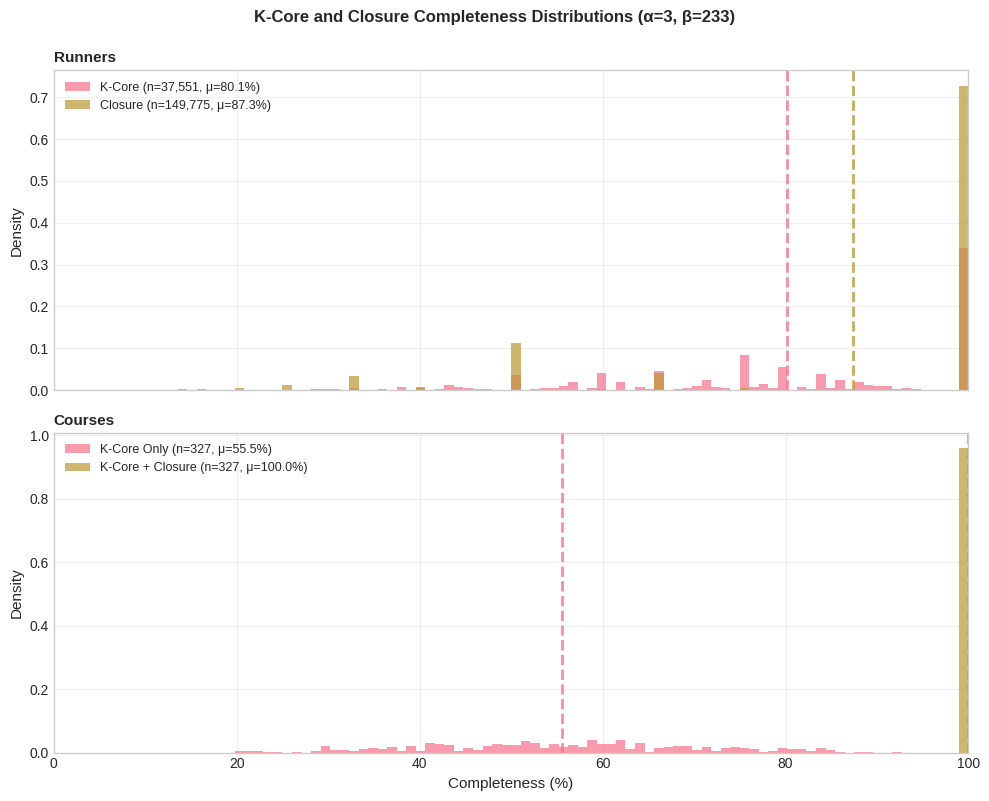

In [7]:
# K-core visualization

# Get k-core and closure entities
kcore_data = model_data[model_data['in_kcore']].copy()
closure_data = model_data[model_data['in_closure']].copy()

# === K-CORE COMPLETENESS ===
# Runner completeness: % of each runner's total courses that are k-core
kcore_runners = kcore_data['participant_id'].unique()
runner_total_courses = results[results['participant_id'].isin(kcore_runners)].groupby('participant_id')['name'].nunique()
runner_kcore_courses = kcore_data.groupby('participant_id')['name'].nunique()
runner_kcore_completeness = (runner_kcore_courses / runner_total_courses * 100).values

# Course completeness: % of each course's total runners that are k-core (vectorized)
kcore_courses = kcore_data[['name', 'distance_miles']].drop_duplicates()
kcore_courses['key'] = kcore_courses['name'] + '_' + kcore_courses['distance_miles'].astype(str)
results['key'] = results['name'] + '_' + results['distance_miles'].astype(str)
kcore_data['key'] = kcore_data['name'] + '_' + kcore_data['distance_miles'].astype(str)

total_runners_per_course = results.groupby('key')['participant_id'].nunique()
kcore_runners_per_course = kcore_data.groupby('key')['participant_id'].nunique()
course_kcore_completeness = (kcore_runners_per_course / total_runners_per_course * 100).reindex(kcore_courses['key']).values

# === CLOSURE COMPLETENESS ===
# Runner completeness: % of each runner's total courses that are in closure
closure_runners = closure_data['participant_id'].unique()
runner_total_courses_closure = results[results['participant_id'].isin(closure_runners)].groupby('participant_id')['name'].nunique()
runner_closure_courses = closure_data.groupby('participant_id')['name'].nunique()
runner_closure_completeness = (runner_closure_courses / runner_total_courses_closure * 100).values

# Course completeness: % of each k-core course's runners that are flagged (k-core OR closure)
# This should be ~100% by design - all participants at k-core courses are flagged

# Create key column without modifying original - use assign to avoid warning
model_data_grouped = model_data.assign(
    key=model_data['name'] + '_' + model_data['distance_miles'].astype(str)
)

# Get all unique courses from model_data (k-core + any additional courses from closure)
all_model_courses = model_data_grouped[['name', 'distance_miles', 'key']].drop_duplicates()

model_runners_per_course = model_data_grouped.groupby('key')['participant_id'].nunique()

# K-core completeness: only for k-core courses
course_kcore_completeness = (kcore_runners_per_course / total_runners_per_course * 100).reindex(kcore_courses['key']).values

# Closure completeness: for all courses in model_data
course_closure_completeness = (model_runners_per_course / total_runners_per_course * 100).reindex(all_model_courses['key']).values

# Calculate optimal bin width using Freedman-Diaconis rule
def freedman_diaconis_bins(data):
    """Calculate number of bins using Freedman-Diaconis rule"""
    q75, q25 = np.percentile(data, [75, 25])
    iqr = q75 - q25
    bin_width = 2 * iqr / (len(data) ** (1/3))
    n_bins = int(np.ceil((data.max() - data.min()) / bin_width))
    return max(10, min(n_bins, 100))  # Ensure reasonable range

# Use all data for bin calculation
all_data = np.concatenate([runner_kcore_completeness, course_kcore_completeness, 
                           runner_closure_completeness, course_closure_completeness])
n_bins = freedman_diaconis_bins(all_data)

# Calculate means
runner_kcore_mean = runner_kcore_completeness.mean()
runner_closure_mean = runner_closure_completeness.mean()
course_kcore_mean = course_kcore_completeness.mean()
course_closure_mean = course_closure_completeness.mean()

# Get counts for legends
n_kcore_courses = len(course_kcore_completeness)
n_all_model_courses = len(course_closure_completeness)

# Create 2-row faceted plot
fig, (ax_runner, ax_course) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Runner panel (top)
ax_runner.hist(runner_kcore_completeness, bins=n_bins, range=(0, 100), density=True, 
               label=f'K-Core (n={len(runner_kcore_completeness):,}, μ={runner_kcore_mean:.1f}%)', color='C0', alpha=0.7, edgecolor='none')
ax_runner.hist(runner_closure_completeness, bins=n_bins, range=(0, 100), density=True, 
               label=f'Closure (n={len(runner_closure_completeness):,}, μ={runner_closure_mean:.1f}%)', color='C1', alpha=0.7, edgecolor='none')

ax_runner.axvline(runner_kcore_mean, linestyle='--', color='C0', linewidth=2, alpha=0.8)
ax_runner.axvline(runner_closure_mean, linestyle='--', color='C1', linewidth=2, alpha=0.8)

ax_runner.set_ylabel('Density', fontsize=11)
ax_runner.set_title('Runners', fontsize=11, fontweight='bold', loc='left')
ax_runner.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax_runner.grid(True, alpha=0.3)
ax_runner.set_xlim(0, 100)

# Course panel (bottom)
ax_course.hist(course_kcore_completeness, bins=n_bins, range=(0, 100), density=True, 
               label=f'K-Core Only (n={n_kcore_courses:,}, μ={course_kcore_mean:.1f}%)', color='C0', alpha=0.7, edgecolor='none')
ax_course.hist(course_closure_completeness, bins=n_bins, range=(0, 100), density=True, 
               label=f'K-Core + Closure (n={n_all_model_courses:,}, μ={course_closure_mean:.1f}%)', color='C1', alpha=0.7, edgecolor='none')

ax_course.axvline(course_kcore_mean, linestyle='--', color='C0', linewidth=2, alpha=0.8)
ax_course.axvline(course_closure_mean, linestyle='--', color='C1', linewidth=2, alpha=0.8)

ax_course.set_xlabel('Completeness (%)', fontsize=11)
ax_course.set_ylabel('Density', fontsize=11)
ax_course.set_title('Courses', fontsize=11, fontweight='bold', loc='left')
ax_course.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax_course.grid(True, alpha=0.3)
ax_course.set_xlim(0, 100)

# Overall title
fig.suptitle(f'K-Core and Closure Completeness Distributions (α={alpha}, β={beta})', 
             fontsize=12, fontweight='bold', y=0.995)

plt.tight_layout()
plt.show()

## Specification

Define the model

### Empirical Priors

Compute empirircal priors on all the results relvant to this model

In [8]:
# Calculate empirical priors from observed data
print("\n" + "="*80)
print("MODEL 2 EMPIRICAL PRIORS")
print("="*80)

# Reference distance for marathon (miles)
REFERENCE_DISTANCE = 26.2
print(f"Reference distance: {REFERENCE_DISTANCE} miles (marathon)\n")

# Create results_finishers (subset of results with finished=True and valid times)
results_finishers = results[results['finished'] & (results['time_ms'] > 0)].copy()

# Identify multi-race participants for k-core filtering
person_counts = results.groupby('participant_id').size()
multi_race_people = person_counts[person_counts >= 2].index

print(f"Data overview:")
print(f"  Total results: {len(results):,}")
print(f"  Finishers: {len(results_finishers):,}")
print(f"  Multi-race participants (≥2 races): {len(multi_race_people):,}")
print()

# FINISH TIME MODEL - Use simple utility functions from empirical_priors module
print("FINISH TIME MODEL (computed from finishers only):")
mu_pace_m = calculate_gender_marathon_pace(results_finishers, 'M', REFERENCE_DISTANCE)
beta_m = calculate_gender_distance_exponent(results_finishers, 'M', REFERENCE_DISTANCE)

mu_pace_f = calculate_gender_marathon_pace(results_finishers, 'F', REFERENCE_DISTANCE)
beta_f = calculate_gender_distance_exponent(results_finishers, 'F', REFERENCE_DISTANCE)

print(f"M (M):")
print(f"  Log marathon pace (mu_pace): {mu_pace_m:.3f}")
print(f"  Marathon pace: {np.exp(mu_pace_m):.2f} min/mile")
print(f"  Distance exponent (beta): {beta_m:.4f}")
print()
print(f"F (F):")
print(f"  Log marathon pace (mu_pace): {mu_pace_f:.3f}")
print(f"  Marathon pace: {np.exp(mu_pace_f):.2f} min/mile")
print(f"  Distance exponent (beta): {beta_f:.4f}")
print()

# Course-level variation - Calculate on k-core subset
model_data_finishers_for_course_calc = results_finishers[results_finishers['participant_id'].isin(multi_race_people)]
sigma_course_prior = calculate_course_variation(model_data_finishers_for_course_calc, REFERENCE_DISTANCE)
print(f"Course variation (sigma_course): {sigma_course_prior:.3f} (from k-core participants)")
print()

# PRIOR WIDTHS: Calculate from empirical data using gender differences
sigma_pace_marathon = 2 * abs(mu_pace_m - mu_pace_f)
sigma_pace_distance_effect = 2 * abs(beta_m - beta_f)

# FINISH TIME NOISE: Domain knowledge prior (not empirically calculated)
# Rationale: Noise is what's left AFTER modeling all effects (gender, distance, course)
# We haven't modeled yet, so we can't know this empirically
# Use domain knowledge: typical within-race CV for ultramarathons is 15-20%
# For log-normal, sigma ≈ CV, so use 0.2 as weakly informative prior scale
sigma_finish_time_noise = 0.1  # Domain knowledge: ~20% CV

print("PRIOR WIDTHS (for weakly informative priors):")
print(f"  pace_marathon sigma: {sigma_pace_marathon:.3f} (2x gender difference)")
print(f"  pace_distance_effect sigma: {sigma_pace_distance_effect:.3f} (2x gender difference)")
print(f"  finish_time_noise sigma: {sigma_finish_time_noise:.2f} (domain knowledge: ~20% CV)")
print(f"    → Cannot calculate empirically - this is residual AFTER all modeling")
print(f"    → Based on typical within-race variation in ultramarathons")
print()

# DNF model parameters - all from empirical priors function
print("DNF MODEL (computed from all results):")
dnf_priors = calculate_dnf_priors(results, REFERENCE_DISTANCE)

mu_logit_dnf = dnf_priors['mu_logit_dnf']
beta_dist_dnf = dnf_priors['beta_dist_dnf']
sigma_course_dnf_prior = dnf_priors['sigma_course_dnf']

# OVERRIDE: Use median course DNF rate instead of marathon-specific rate
# The marathon baseline (4% DNF) is too low for the typical ultra course (~30% DNF)
# This causes the prior to predict too many courses with near-zero DNF rates
course_dnf_rates = results.groupby('name')['finished'].apply(lambda x: (~x).mean())
median_course_dnf_rate = course_dnf_rates.median()
median_course_dnf_rate = np.clip(median_course_dnf_rate, 0.01, 0.99)

# BOOST the baseline slightly above median to match observed peak around 0.35
# Median is ~0.3 but observed distributions peak around 0.35
median_course_dnf_rate = median_course_dnf_rate * 1.15  # Boost by 15%
median_course_dnf_rate = np.clip(median_course_dnf_rate, 0.01, 0.99)
mu_logit_dnf = float(np.log(median_course_dnf_rate / (1 - median_course_dnf_rate)))

# OVERRIDE: Reduce course-level DNF variation to prevent extreme predictions
# The empirical sigma_course_dnf is calculated from ALL courses (including outliers)
# This creates too much variation, predicting both peaks at 0 and tails at >0.6
# Scale down by 60% to further constrain high DNF predictions
sigma_course_dnf_prior = sigma_course_dnf_prior * 0.4

# OVERRIDE: Reduce distance effect to prevent extreme DNF predictions at long distances
# The empirical beta_dist_dnf creates too much increase for 100K/100mi races
# Scale down by 30% to reduce the right tail of high DNF rate predictions
beta_dist_dnf = beta_dist_dnf * 0.7

print(f"  Baseline DNF log-odds (MEDIAN COURSE + 15%): {mu_logit_dnf:.3f}")
print(f"  → Corresponds to DNF rate: {median_course_dnf_rate:.3f}")
print(f"  Distance effect on DNF (beta_dist_dnf): {beta_dist_dnf:.3f} (scaled down 30%)")
print(f"  Course-level DNF variation (sigma_course_dnf): {sigma_course_dnf_prior:.3f} (scaled down 60%)")
print()

# Calculate prior widths for DNF hyperparameters
# For mu_logit_dnf: Use course-level variation as uncertainty
sigma_dnf_rate_marathon = sigma_course_dnf_prior  # Use empirical course variation

# For beta_dist_dnf: Use a conservative fraction of the estimate itself
sigma_dnf_distance_multiplier = abs(beta_dist_dnf) * 0.5  # 50% uncertainty

print(f"DNF PRIOR WIDTHS:")
print(f"  dnf_rate_marathon sigma: {sigma_dnf_rate_marathon:.3f} (course variation)")
print(f"  dnf_distance_multiplier sigma: {sigma_dnf_distance_multiplier:.3f} (50% of estimate)")

print("="*80 + "\n")


MODEL 2 EMPIRICAL PRIORS
Reference distance: 26.2 miles (marathon)

Data overview:
  Total results: 892,769
  Finishers: 796,271
  Multi-race participants (≥2 races): 123,704

FINISH TIME MODEL (computed from finishers only):
M (M):
  Log marathon pace (mu_pace): 2.641
  Marathon pace: 14.03 min/mile
  Distance exponent (beta): 0.2040

F (F):
  Log marathon pace (mu_pace): 2.728
  Marathon pace: 15.30 min/mile
  Distance exponent (beta): 0.1510

Course variation (sigma_course): 0.148 (from k-core participants)

PRIOR WIDTHS (for weakly informative priors):
  pace_marathon sigma: 0.173 (2x gender difference)
  pace_distance_effect sigma: 0.106 (2x gender difference)
  finish_time_noise sigma: 0.10 (domain knowledge: ~20% CV)
    → Cannot calculate empirically - this is residual AFTER all modeling
    → Based on typical within-race variation in ultramarathons

DNF MODEL (computed from all results):
  Baseline DNF log-odds (MEDIAN COURSE + 15%): -1.876
  → Corresponds to DNF rate: 0.133


In [9]:
# Extract model arrays from subsetted data
# Separate finishers (for finish time model) from all results (for DNF model)
model_data_finishers = model_data[model_data['finished'] & (model_data['time_ms'] > 0)].copy()

# Create categorical indices for vectorized operations
unique_courses = model_data['name'].unique()
unique_genders = np.array(['M', 'F'])

# Map courses and genders to integer indices
course_to_idx = {course: idx for idx, course in enumerate(unique_courses)}
gender_to_idx = {'M': 0, 'F': 1}

# Finish time model data (finishers only)
course_indices_finishers = model_data_finishers['name'].map(course_to_idx).values
gender_indices_finishers = model_data_finishers['gender'].map(gender_to_idx).values
distances_finishers = model_data_finishers['distance_miles'].values
observed_times_finishers = model_data_finishers['time_ms'].values / 60_000  # Convert to minutes

# DNF model data (all results)
course_indices_results = model_data['name'].map(course_to_idx).values
distances_results = model_data['distance_miles'].values
did_finish = model_data['finished'].values.astype(int)

n_courses = len(unique_courses)
n_runners = model_data['participant_id'].nunique()

# PERFORMANCE OPTIMIZATION: Pre-compute course distances BEFORE model definition
# This prevents Python loops inside the PyMC model context (enables JAX compilation)
unique_course_distances = np.array([
    distances_finishers[course_indices_finishers == i].mean() 
    if (course_indices_finishers == i).any()
    else (distances_results[course_indices_results == i].mean()
          if (course_indices_results == i).any()
          else REFERENCE_DISTANCE)
    for i in range(n_courses)
])
unique_log_distance_ratios = np.log(unique_course_distances / REFERENCE_DISTANCE)

# PERFORMANCE OPTIMIZATION: Pre-compute log distance ratios (avoid computing logs every MCMC iteration)
log_distance_ratio_finishers = np.log(distances_finishers / REFERENCE_DISTANCE)
log_distances_finishers = np.log(distances_finishers)

print(f"Model data prepared:")

print(f"  Runners: {n_runners:,}")
print(f"  Total results (finishers + DNFs): {len(did_finish):,}")

print(f"  Courses: {n_courses:,}")
print(f"  Finisher observations: {len(observed_times_finishers):,}")

Model data prepared:
  Runners: 187,326
  Total results (finishers + DNFs): 591,435
  Courses: 327
  Finisher observations: 535,794


### Generative Model

In [10]:
def define_model(model_data, fixed_params=None):
    """
    Define the hierarchical Bayesian model for ultramarathon finish times and DNF rates.
    
    This function builds the complete model structure with correlated course effects.
    Hyperparameters can either be estimated via priors (MCMC) or fixed at provided values (MAP).
    
    Parameters
    ----------
    model_data : pd.DataFrame
        DataFrame containing race results with columns: name (course), gender, distance_miles, 
        time_ms (for finishers), finished (bool)
    fixed_params : dict, optional
        Dictionary of hyperparameter values to fix. If None, all parameters are estimated.
        Expected keys (when provided):
        - 'pace_marathon': array of length 2 [M, F]
        - 'pace_distance_effect': array of length 2 [M, F]
        - 'dnf_rate_marathon': scalar
        - 'dnf_distance_multiplier': scalar
        - 'chol': pre-computed Cholesky matrix (2x2)
        If any key is missing, that parameter will be estimated via priors.
    
    Returns
    -------
    pm.Model
        PyMC model ready for sampling (MCMC) or optimization (MAP)
    """
    
    # === PREPARE DATA ARRAYS ===
    
    # Extract unique coordinate values
    unique_courses = model_data['name'].unique()
    unique_genders = np.array(['M', 'F'])
    
    # Create mappings
    course_to_idx = {course: idx for idx, course in enumerate(unique_courses)}
    gender_to_idx = {'M': 0, 'F': 1}
    
    # Prepare finisher data
    finishers = model_data[model_data['finished'] & (model_data['time_ms'] > 0)].copy()
    distances_finishers = finishers['distance_miles'].values
    gender_indices_finishers = finishers['gender'].map(gender_to_idx).values
    course_indices_finishers = finishers['name'].map(course_to_idx).values
    observed_times_finishers = finishers['time_ms'].values / 60_000  # Convert to minutes
    log_distances_finishers = np.log(distances_finishers)
    log_distance_ratio_finishers = np.log(distances_finishers / REFERENCE_DISTANCE)
    
    # Prepare DNF data (all results)
    # CHANGED: Flip the coding so did_finish represents DNF (1=DNF, 0=finished)
    # This matches the DNF semantics of logit_p_dnf
    distances_results = model_data['distance_miles'].values
    course_indices_results = model_data['name'].map(course_to_idx).values
    did_finish = (~model_data['finished']).values.astype(int)  # 1=DNF, 0=finished
    
    # Compute log distance ratios for each unique course
    unique_course_distances = np.array([
        distances_finishers[course_indices_finishers == i].mean() 
        if (course_indices_finishers == i).any()
        else (distances_results[course_indices_results == i].mean()
              if (course_indices_results == i).any()
              else REFERENCE_DISTANCE)
        for i in range(len(unique_courses))
    ])
    unique_log_distance_ratios = np.log(unique_course_distances / REFERENCE_DISTANCE)
    
    # Define coordinates for PyMC
    coords = {
        'course': unique_courses,
        'gender': unique_genders,
        'course_effect_type': ['finish_time_total', 'dnf_total'],
        'finishers': np.arange(len(observed_times_finishers)),
        'obs_results': np.arange(len(did_finish)),
    }
    
    # === BUILD MODEL ===
    
    model = pm.Model(coords=coords)
    
    with model:
        
        # --- HYPERPARAMETERS ---
        # Either estimated via priors or fixed at provided values
        
        is_fixed_mode = fixed_params is not None
        
        if is_fixed_mode and 'pace_marathon' in fixed_params:
            pace_marathon = pm.Data('pace_marathon', fixed_params['pace_marathon'], dims='gender')
        else:
            pace_marathon = pm.Normal('pace_marathon', mu=[mu_pace_m, mu_pace_f], 
                                     sigma=sigma_pace_marathon, dims='gender')
        
        if is_fixed_mode and 'pace_distance_effect' in fixed_params:
            pace_distance_effect = pm.Data('pace_distance_effect', 
                                          fixed_params['pace_distance_effect'], dims='gender')
        else:
            pace_distance_effect = pm.Normal('pace_distance_effect', mu=[beta_m, beta_f], 
                                            sigma=sigma_pace_distance_effect, dims='gender')
        
        # Finish time noise - always fixed at sigma_finish_time_noise constant
        if is_fixed_mode:
            finish_time_noise = np.array([sigma_finish_time_noise, sigma_finish_time_noise])
        else:
            finish_time_noise = pm.HalfNormal('finish_time_noise', sigma=sigma_finish_time_noise, 
                                             dims='gender')
        
        if is_fixed_mode and 'dnf_rate_marathon' in fixed_params:
            dnf_rate_marathon = pm.Data('dnf_rate_marathon', fixed_params['dnf_rate_marathon'])
        else:
            dnf_rate_marathon = pm.Normal('dnf_rate_marathon', mu=mu_logit_dnf, 
                                         sigma=sigma_dnf_rate_marathon)
        
        if is_fixed_mode and 'dnf_distance_multiplier' in fixed_params:
            dnf_distance_multiplier = pm.Data('dnf_distance_multiplier', 
                                             fixed_params['dnf_distance_multiplier'])
        else:
            dnf_distance_multiplier = pm.Normal('dnf_distance_multiplier', mu=beta_dist_dnf, 
                                               sigma=sigma_dnf_distance_multiplier)
        
        # --- DISTANCE BASELINES ---
        
        pace_marathon_avg = (pace_marathon[0] + pace_marathon[1]) / 2
        pace_distance_effect_avg = (pace_distance_effect[0] + pace_distance_effect[1]) / 2
        
        course_distance_finish_baseline = (
            pace_marathon_avg +
            pace_distance_effect_avg * unique_log_distance_ratios
        )
        
        course_distance_dnf_baseline = (
            dnf_rate_marathon +
            dnf_distance_multiplier * unique_log_distance_ratios
        )
        
        # --- CORRELATED COURSE EFFECTS ---
        
        if is_fixed_mode and 'chol' in fixed_params:
            # Use pre-computed Cholesky matrix
            chol = pt.as_tensor_variable(fixed_params['chol'])
        else:
            # Estimate correlation structure via LKJCholeskyCov
            chol, corr, stds = pm.LKJCholeskyCov(
                'course_chol',
                n=2,
                eta=2.0,
                sd_dist=pm.HalfNormal.dist(
                    sigma=[sigma_course_prior, sigma_course_dnf_prior]
                ),
                compute_corr=True
            )
        
        # Non-centered parameterization with standard normal raw effects
        course_effects_raw = pm.Normal(
            'course_effects_raw', 
            mu=0, 
            sigma=1,
            dims=('course', 'course_effect_type')
        )
        
        # Transform to correlated effects with proper scaling
        course_effects_centered = pm.Deterministic('course_effects_centered',
                                                   pm.math.dot(course_effects_raw, chol),
                                                   dims=('course', 'course_effect_type'))
        
        # Add distance baselines to get total effects (in log-space)
        course_total_finish_effect = course_distance_finish_baseline + course_effects_centered[:, 0]
        course_total_dnf_effect = course_distance_dnf_baseline + course_effects_centered[:, 1]
        
        # --- LIKELIHOOD ---
        
        # FINISH TIME MODEL (LogNormal)
        # Compute gender deviation from population average (in log-space)
        gender_deviation = (
            pace_marathon[gender_indices_finishers] - pace_marathon_avg +
            (pace_distance_effect[gender_indices_finishers] - pace_distance_effect_avg) * 
            log_distance_ratio_finishers
        )
        
        # OPTIMIZATION: Stay in log-space throughout
        expected_log_pace = course_total_finish_effect[course_indices_finishers] + gender_deviation
        expected_log_time = expected_log_pace + log_distances_finishers
        
        # LogNormal likelihood
        finish_likelihood = pm.LogNormal(
            'finisher_times',
            mu=expected_log_time,
            sigma=finish_time_noise[gender_indices_finishers],
            observed=observed_times_finishers,
            dims='finishers'
        )
        
        # DNF MODEL (additive effects on logit scale)
        # logit_p_dnf represents logit(P(DNF))
        logit_p_dnf = course_total_dnf_effect[course_indices_results]
        
        # CHANGED: Removed negation - now directly modeling P(DNF)
        # Bernoulli likelihood: did_finish is now coded as 1=DNF, 0=finished
        pm.Bernoulli('did_finish_obs', p=pm.math.invlogit(logit_p_dnf), 
                    observed=did_finish, dims='obs_results')
    
    return model

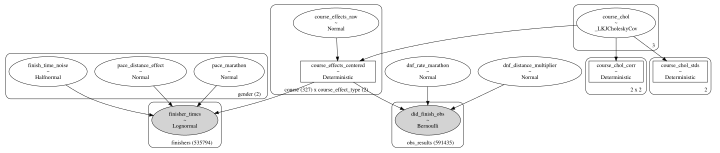

In [11]:
# Build MCMC model with all hyperparameters estimated via priors
model = define_model(model_data, fixed_params=None)

# Display model structure
graph = pm.model_to_graphviz(model)
graph.graph_attr['size'] = '10,12'

graph.render(model_dir / 'model_graph', format='png', cleanup=True)

graph

In [12]:
# Helper function to transform log-space course effects to interpretable multipliers
# This is needed because we stay in log-space during sampling but need linear-space for visualization
def compute_course_multipliers_from_trace(trace):
    """
    Transform log-space course effects to interpretable pace multipliers.
    Used for visualizations after sampling.
    
    Args:
        trace: ArviZ InferenceData object with posterior samples
        
    Returns:
        Array of course multipliers (shape: chains × draws × n_courses)
    """
    # Extract centered effects (in log-space for finish times)
    course_effects_centered = trace.posterior['course_effects_centered']
    
    # For finish times: multiplier = exp(effect)
    # NOTE: Since we removed max(effect, 0) clipping from the model, 
    # multipliers can now be < 1.0 (courses that make you faster)
    # Use .sel() to select the finish_time dimension by name
    finish_effects = course_effects_centered.sel(course_effect_type='finish_time_total')
    course_multipliers_finish = np.exp(finish_effects.values)
    
    return course_multipliers_finish

In [13]:
# Sample from prior
with model:
    prior_pred = pm.sample_prior_predictive(samples=1000, random_seed=42)

/usr/local/lib/python3.12/dist-packages/pytensor/link/c/cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(
Sampling: [course_chol, course_effects_raw, did_finish_obs, dnf_distance_multiplier, dnf_rate_marathon, finish_time_noise, finisher_times, pace_distance_effect, pace_marathon]


### Prior Visualization

/tmp/ipykernel_4114/4261953810.py:168: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=course_finish_time_std_interpretable, ax=ax,
/tmp/ipykernel_4114/4261953810.py:185: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=course_dnf_std_interpretable, ax=ax,
/tmp/ipykernel_4114/4261953810.py:202: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=course_correlation_flat, ax=ax, color='#8B0000', linewidth=2.5, fill=False)


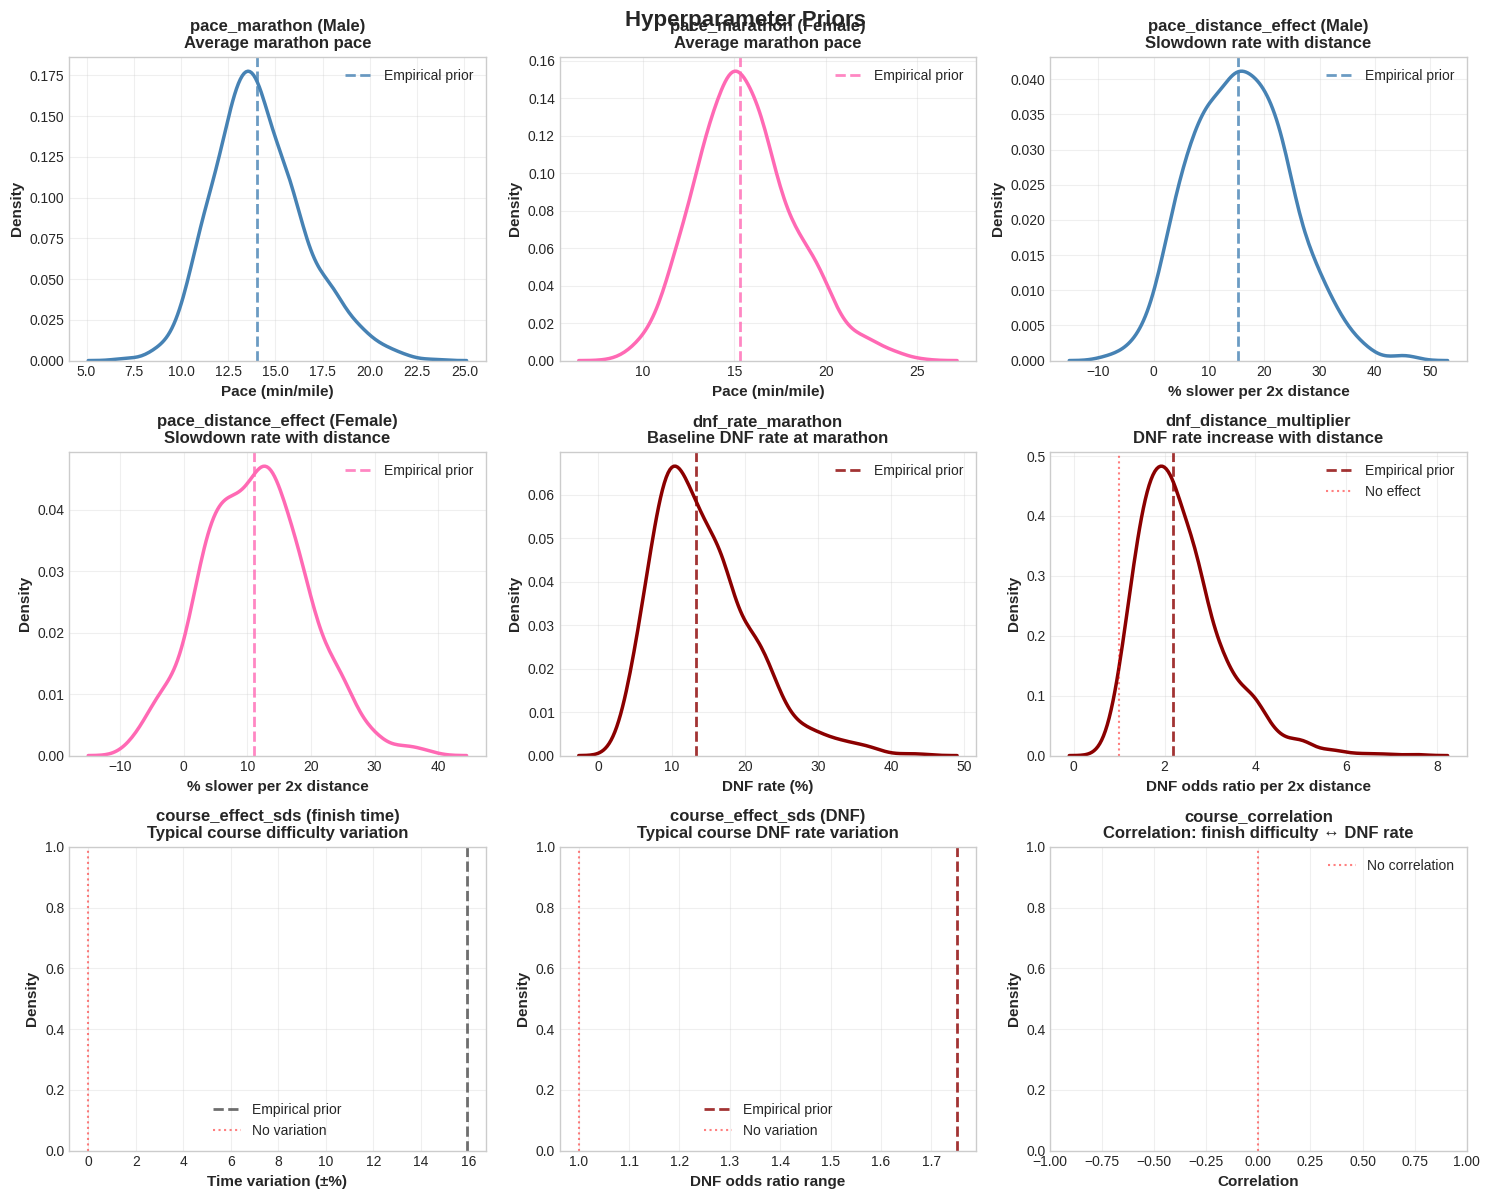

In [14]:
# Prior Distribution Visualizations
# Extract prior samples from prior_pred and plot as KDEs to show theoretical distributions
n_genders = len(unique_genders)  # Compute locally

pace_marathon_prior = prior_pred.prior["pace_marathon"].values  # Shape: (chains, draws, n_genders)
pace_distance_effect_prior = prior_pred.prior["pace_distance_effect"].values
# NOTE: finish_time_noise is now estimated (HalfNormal prior)
finish_time_noise_prior = prior_pred.prior["finish_time_noise"].values  # Shape: (chains, draws, n_genders)
dnf_rate_marathon_prior = prior_pred.prior["dnf_rate_marathon"].values  # Scalar
dnf_distance_multiplier_prior = prior_pred.prior["dnf_distance_multiplier"].values  # Scalar

# Extract hyperparameters from chol matrix (removed as Deterministic for performance)
chol_prior_xr = prior_pred.prior["course_chol"]  # xarray with named dimensions
chol_prior = chol_prior_xr.values  # Convert to numpy array
# Cholesky: L = [[a, 0], [b, c]], Stds: [a, sqrt(b^2 + c^2)], Corr: b / (a * sqrt(b^2 + c^2))

# Check dimensions and handle accordingly
if chol_prior.ndim == 3:
    # Shape is (chains*draws, 2, 2) - already flattened
    course_effect_sds_prior = np.stack([
        chol_prior[:, 0, 0],  # Finish time SD  
        np.sqrt(chol_prior[:, 1, 0]**2 + chol_prior[:, 1, 1]**2)  # DNF SD
    ], axis=-1)  # Shape: (samples, 2)
    course_correlation_prior = chol_prior[:, 1, 0] / (
        chol_prior[:, 0, 0] * np.sqrt(chol_prior[:, 1, 0]**2 + chol_prior[:, 1, 1]**2)
    )  # Shape: (samples,)
else:
    # Shape is (chains, draws, 2, 2) - need to extract chains/draws
    course_effect_sds_prior = np.stack([
        chol_prior[:, :, 0, 0],  # Finish time SD
        np.sqrt(chol_prior[:, :, 1, 0]**2 + chol_prior[:, :, 1, 1]**2)  # DNF SD
    ], axis=-1)  # Shape: (chains, draws, 2)
    course_correlation_prior = chol_prior[:, :, 1, 0] / (
        chol_prior[:, :, 0, 0] * np.sqrt(chol_prior[:, :, 1, 0]**2 + chol_prior[:, :, 1, 1]**2)
    )  # Scalar correlation

# Flatten to (samples,) for scalar parameters or (samples, dim) for vector parameters
pace_marathon_flat = pace_marathon_prior.reshape(-1, n_genders)
pace_distance_effect_flat = pace_distance_effect_prior.reshape(-1, n_genders)
finish_time_noise_flat = finish_time_noise_prior.reshape(-1, n_genders)
dnf_rate_marathon_flat = dnf_rate_marathon_prior.flatten()
dnf_distance_multiplier_flat = dnf_distance_multiplier_prior.flatten()
course_effect_sds_flat = course_effect_sds_prior.reshape(-1, 2)  # (samples, 2): [finish, dnf]
course_correlation_flat = course_correlation_prior.flatten()  # Scalar correlation parameter

# Convert to interpretable units
# pace_marathon: exp(log pace) = pace in min/mile
pace_marathon_interpretable = np.exp(pace_marathon_flat)

# pace_distance_effect: convert to % slowdown per 2x distance increase
pace_distance_effect_interpretable = (np.power(2, pace_distance_effect_flat) - 1) * 100

# finish_time_noise: convert from log-scale sigma to coefficient of variation (%)
finish_time_noise_interpretable = finish_time_noise_flat * 100

# DNF parameters: convert from logit scale to probability/percentage for marathon distance
dnf_prob_marathon_pct = (1 / (1 + np.exp(-dnf_rate_marathon_flat))) * 100

# dnf_distance_multiplier: convert to odds ratio per 2x distance increase
dnf_distance_multiplier_interpretable = np.exp(dnf_distance_multiplier_flat * np.log(2))

# course_effect_sds: separate finish time and DNF standard deviations
# Finish time: convert from log SD to typical % variation
course_finish_time_std_interpretable = (np.exp(course_effect_sds_flat[:, 0]) - 1) * 100
# DNF: convert from logit SD to odds ratio range
course_dnf_std_interpretable = np.exp(course_effect_sds_flat[:, 1])

# Create figure with 3 rows x 3 columns (9 subplots)
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

# 1. pace_marathon - Male (vector)
ax = axes[0]
sns.kdeplot(data=pace_marathon_interpretable[:, 0], ax=ax, 
           color='steelblue', linewidth=2.5, fill=False)

# Add empirical prior reference (marathon pace for males)
empirical_pace_m = np.exp(mu_pace_m)
ax.axvline(x=empirical_pace_m, color='steelblue', linestyle='--', 
          linewidth=2, alpha=0.8, label='Empirical prior')

ax.set_xlabel('Pace (min/mile)', fontsize=11, fontweight='bold')
ax.set_ylabel('Density', fontsize=11, fontweight='bold')
ax.set_title('pace_marathon (Male)\nAverage marathon pace', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 2. pace_marathon - Female (vector)
ax = axes[1]
sns.kdeplot(data=pace_marathon_interpretable[:, 1], ax=ax, 
           color='#FF69B4', linewidth=2.5, fill=False)

# Add empirical prior reference (marathon pace for females)
empirical_pace_f = np.exp(mu_pace_f)
ax.axvline(x=empirical_pace_f, color='#FF69B4', linestyle='--', 
          linewidth=2, alpha=0.8, label='Empirical prior')

ax.set_xlabel('Pace (min/mile)', fontsize=11, fontweight='bold')
ax.set_ylabel('Density', fontsize=11, fontweight='bold')
ax.set_title('pace_marathon (Female)\nAverage marathon pace', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 3. pace_distance_effect - Male (vector) - as % slowdown per 2x distance increase
ax = axes[2]
sns.kdeplot(data=pace_distance_effect_interpretable[:, 0], ax=ax, 
           color='steelblue', linewidth=2.5, fill=False)

empirical_dist_effect_m = (2**beta_m - 1) * 100
ax.axvline(x=empirical_dist_effect_m, color='steelblue', linestyle='--', 
          linewidth=2, alpha=0.8, label='Empirical prior')

ax.set_xlabel('% slower per 2x distance', fontsize=11, fontweight='bold')
ax.set_ylabel('Density', fontsize=11, fontweight='bold')
ax.set_title('pace_distance_effect (Male)\nSlowdown rate with distance', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 4. pace_distance_effect - Female (vector) - as % slowdown per 2x distance increase
ax = axes[3]
sns.kdeplot(data=pace_distance_effect_interpretable[:, 1], ax=ax, 
           color='#FF69B4', linewidth=2.5, fill=False)

empirical_dist_effect_f = (2**beta_f - 1) * 100
ax.axvline(x=empirical_dist_effect_f, color='#FF69B4', linestyle='--', 
          linewidth=2, alpha=0.8, label='Empirical prior')

ax.set_xlabel('% slower per 2x distance', fontsize=11, fontweight='bold')
ax.set_ylabel('Density', fontsize=11, fontweight='bold')
ax.set_title('pace_distance_effect (Female)\nSlowdown rate with distance', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 5. dnf_rate_marathon (scalar) - as % DNF at marathon distance
ax = axes[4]
sns.kdeplot(data=dnf_prob_marathon_pct, ax=ax, color='#8B0000', linewidth=2.5, fill=False)

# Empirical prior
empirical_dnf_pct = (1 / (1 + np.exp(-mu_logit_dnf))) * 100
ax.axvline(x=empirical_dnf_pct, color='#8B0000', linestyle='--', 
          linewidth=2, alpha=0.8, label='Empirical prior')

ax.set_xlabel('DNF rate (%)', fontsize=11, fontweight='bold')
ax.set_ylabel('Density', fontsize=11, fontweight='bold')
ax.set_title('dnf_rate_marathon\nBaseline DNF rate at marathon', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 6. dnf_distance_multiplier (scalar) - as odds ratio per 2x distance increase
ax = axes[5]
sns.kdeplot(data=dnf_distance_multiplier_interpretable, ax=ax, 
           color='#8B0000', linewidth=2.5, fill=False)

empirical_dnf_multiplier = np.exp(beta_dist_dnf * np.log(2))
ax.axvline(x=empirical_dnf_multiplier, color='#8B0000', linestyle='--', 
          linewidth=2, alpha=0.8, label='Empirical prior')
ax.axvline(x=1.0, color='red', linestyle=':', linewidth=1.5, alpha=0.5, 
          label='No effect')

ax.set_xlabel('DNF odds ratio per 2x distance', fontsize=11, fontweight='bold')
ax.set_ylabel('Density', fontsize=11, fontweight='bold')
ax.set_title('dnf_distance_multiplier\nDNF rate increase with distance', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 6. course_effect_sds - Finish time (scalar) - as % variation
ax = axes[6]
sns.kdeplot(data=course_finish_time_std_interpretable, ax=ax, 
           color='#4a4a4a', linewidth=2.5, fill=False)

empirical_finish_time_pct = (np.exp(sigma_course_prior) - 1) * 100
ax.axvline(x=empirical_finish_time_pct, color='#4a4a4a', linestyle='--', 
          linewidth=2, alpha=0.8, label='Empirical prior')
ax.axvline(x=0, color='red', linestyle=':', linewidth=1.5, alpha=0.5, 
          label='No variation')

ax.set_xlabel('Time variation (±%)', fontsize=11, fontweight='bold')
ax.set_ylabel('Density', fontsize=11, fontweight='bold')
ax.set_title('course_effect_sds (finish time)\nTypical course difficulty variation', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 7. course_effect_sds - DNF (scalar) - as odds ratio
ax = axes[7]
sns.kdeplot(data=course_dnf_std_interpretable, ax=ax, 
           color='#8B0000', linewidth=2.5, fill=False)

empirical_dnf_odds_ratio = np.exp(sigma_course_dnf_prior)
ax.axvline(x=empirical_dnf_odds_ratio, color='#8B0000', linestyle='--', 
          linewidth=2, alpha=0.8, label='Empirical prior')
ax.axvline(x=1.0, color='red', linestyle=':', linewidth=1.5, alpha=0.5, 
          label='No variation')

ax.set_xlabel('DNF odds ratio range', fontsize=11, fontweight='bold')
ax.set_ylabel('Density', fontsize=11, fontweight='bold')
ax.set_title('course_effect_sds (DNF)\nTypical course DNF rate variation', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# 8. course_correlation (scalar) - THE KEY PARAMETER for selection bias quantification
ax = axes[8]
sns.kdeplot(data=course_correlation_flat, ax=ax, color='#8B0000', linewidth=2.5, fill=False)

# No empirical prior for correlation (learned from LKJ)
ax.axvline(x=0.0, color='red', linestyle=':', linewidth=1.5, alpha=0.5, 
          label='No correlation')

ax.set_xlabel('Correlation', fontsize=11, fontweight='bold')
ax.set_ylabel('Density', fontsize=11, fontweight='bold')
ax.set_title('course_correlation\nCorrelation: finish difficulty ↔ DNF rate', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

ax.set_xlim(-1, 1)

plt.tight_layout()
plt.suptitle('Hyperparameter Priors', fontsize=16, fontweight='bold', y=0.995)
plt.show()


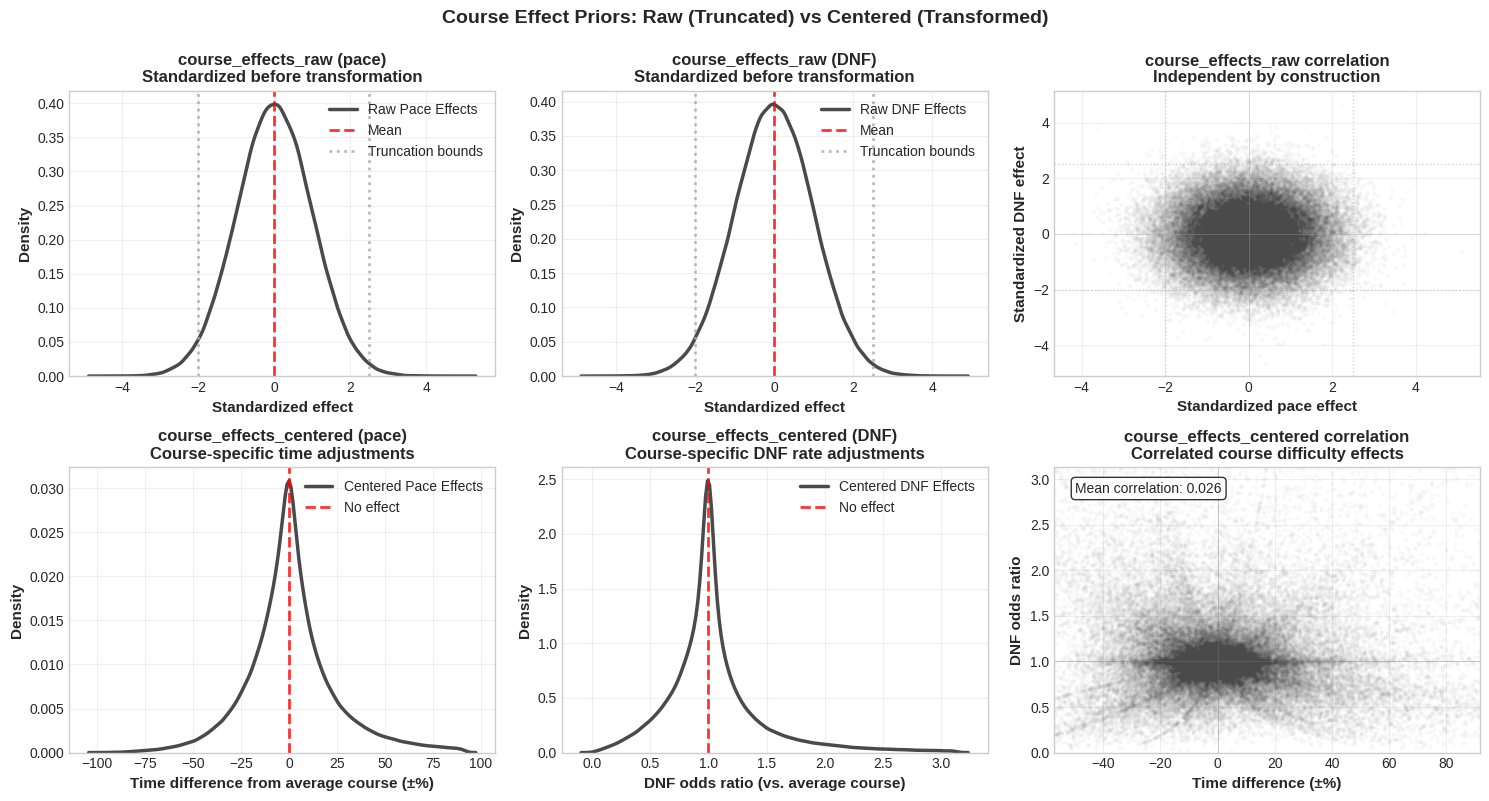

In [15]:
# Course Effect Priors
# Extract BOTH raw (truncated) and centered (transformed) course effects
course_effects_raw_prior = prior_pred.prior["course_effects_raw"]  # xarray with dims: (chain, draw, course, course_effect_type)
course_effects_centered_prior = prior_pred.prior["course_effects_centered"]  # xarray with dims: (chain, draw, course, course_effect_type)

# Use .sel() to select by dimension name, then flatten
n_samples = course_effects_raw_prior.sizes['chain'] * course_effects_raw_prior.sizes['draw']
course_pace_raw = course_effects_raw_prior.sel(course_effect_type='finish_time_total').values.reshape(n_samples, -1)
course_dnf_raw = course_effects_raw_prior.sel(course_effect_type='dnf_total').values.reshape(n_samples, -1)
course_pace_centered = course_effects_centered_prior.sel(course_effect_type='finish_time_total').values.reshape(n_samples, -1)
course_dnf_centered = course_effects_centered_prior.sel(course_effect_type='dnf_total').values.reshape(n_samples, -1)

# Transform centered effects to interpretable units
course_pace_centered_pct = (np.exp(course_pace_centered) - 1) * 100  # Convert log scale to ±%
course_dnf_centered_odds = np.exp(course_dnf_centered)  # Convert log odds to odds ratio

# Create figure with 2 rows x 3 columns
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# ===== ROW 1: RAW EFFECTS (where truncation is applied) =====
# Plot 1: Distribution of raw course pace effects (TRUNCATED)
ax = axes[0, 0]
all_pace_raw = course_pace_raw.flatten()
sns.kdeplot(data=all_pace_raw, ax=ax, color='#4a4a4a', linewidth=2.5, 
            fill=False, label='Raw Pace Effects')
ax.axvline(0, color='red', linestyle='--', linewidth=2, alpha=0.8, label='Mean')
ax.axvline(-2, color='darkgray', linestyle=':', linewidth=2, alpha=0.8, label='Truncation bounds')
ax.axvline(2.5, color='darkgray', linestyle=':', linewidth=2, alpha=0.8)
ax.set_xlabel('Standardized effect', fontsize=11, fontweight='bold')
ax.set_ylabel('Density', fontsize=11, fontweight='bold')
ax.set_title('course_effects_raw (pace)\nStandardized before transformation', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Plot 2: Distribution of raw course DNF effects (TRUNCATED)
ax = axes[0, 1]
all_dnf_raw = course_dnf_raw.flatten()
sns.kdeplot(data=all_dnf_raw, ax=ax, color='#4a4a4a', linewidth=2.5, 
            fill=False, label='Raw DNF Effects')
ax.axvline(0, color='red', linestyle='--', linewidth=2, alpha=0.8, label='Mean')
ax.axvline(-2, color='darkgray', linestyle=':', linewidth=2, alpha=0.8, label='Truncation bounds')
ax.axvline(2.5, color='darkgray', linestyle=':', linewidth=2, alpha=0.8)
ax.set_xlabel('Standardized effect', fontsize=11, fontweight='bold')
ax.set_ylabel('Density', fontsize=11, fontweight='bold')
ax.set_title('course_effects_raw (DNF)\nStandardized before transformation', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Plot 3: Correlation in raw effects (before Cholesky transform)
ax = axes[0, 2]
n_viz_samples = min(1000, n_samples)
sample_indices = np.random.choice(n_samples, n_viz_samples, replace=False)

for i in sample_indices[:200]:
    ax.scatter(course_pace_raw[i, :], course_dnf_raw[i, :], 
              alpha=0.02, s=5, color='#4a4a4a')

ax.axhline(0, color='darkgray', linestyle='-', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='darkgray', linestyle='-', linewidth=0.5, alpha=0.5)
ax.axhline(-2, color='darkgray', linestyle=':', linewidth=1, alpha=0.5)
ax.axhline(2.5, color='darkgray', linestyle=':', linewidth=1, alpha=0.5)
ax.axvline(-2, color='darkgray', linestyle=':', linewidth=1, alpha=0.5)
ax.axvline(2.5, color='darkgray', linestyle=':', linewidth=1, alpha=0.5)
ax.set_xlabel('Standardized pace effect', fontsize=11, fontweight='bold')
ax.set_ylabel('Standardized DNF effect', fontsize=11, fontweight='bold')
ax.set_title('course_effects_raw correlation\nIndependent by construction', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)

# ===== ROW 2: CENTERED EFFECTS (after scaling & correlation) =====
# Plot 4: Distribution of centered course pace effects
ax = axes[1, 0]
all_pace_centered_pct = course_pace_centered_pct.flatten()
# Clip extreme values for visualization (keep 98% of data)
pace_98p = np.percentile(all_pace_centered_pct, 98)
all_pace_centered_pct_clipped = all_pace_centered_pct[all_pace_centered_pct <= pace_98p]
sns.kdeplot(data=all_pace_centered_pct_clipped, ax=ax, color='#4a4a4a', linewidth=2.5, 
            fill=False, label='Centered Pace Effects')
ax.axvline(0, color='red', linestyle='--', linewidth=2, alpha=0.8, label='No effect')
ax.set_xlabel('Time difference from average course (±%)', fontsize=11, fontweight='bold')
ax.set_ylabel('Density', fontsize=11, fontweight='bold')
ax.set_title('course_effects_centered (pace)\nCourse-specific time adjustments', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Plot 5: Distribution of centered course DNF effects
ax = axes[1, 1]
all_dnf_centered_odds = course_dnf_centered_odds.flatten()
# Clip extreme values for visualization (keep 98% of data)
dnf_98p = np.percentile(all_dnf_centered_odds, 98)
all_dnf_centered_odds_clipped = all_dnf_centered_odds[all_dnf_centered_odds <= dnf_98p]
sns.kdeplot(data=all_dnf_centered_odds_clipped, ax=ax, color='#4a4a4a', linewidth=2.5, 
            fill=False, label='Centered DNF Effects')
ax.axvline(1.0, color='red', linestyle='--', linewidth=2, alpha=0.8, label='No effect')
ax.set_xlabel('DNF odds ratio (vs. average course)', fontsize=11, fontweight='bold')
ax.set_ylabel('Density', fontsize=11, fontweight='bold')
ax.set_title('course_effects_centered (DNF)\nCourse-specific DNF rate adjustments', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

# Plot 6: Correlation in centered effects (after Cholesky transform)
ax = axes[1, 2]
for i in sample_indices[:200]:
    ax.scatter(course_pace_centered_pct[i, :], course_dnf_centered_odds[i, :], 
              alpha=0.02, s=5, color='#4a4a4a')

ax.axhline(1.0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)
ax.set_xlabel('Time difference (±%)', fontsize=11, fontweight='bold')
ax.set_ylabel('DNF odds ratio', fontsize=11, fontweight='bold')
ax.set_title('course_effects_centered correlation\nCorrelated course difficulty effects', fontsize=12, fontweight='bold')
# Use percentile-based limits to match the distribution plots
ax.set_xlim(np.percentile(course_pace_centered_pct, 1), pace_98p)
ax.set_ylim(0, dnf_98p)
ax.grid(alpha=0.3)

# Add correlation coefficient
sample_corrs = []
for i in range(min(100, n_samples)):
    corr = np.corrcoef(course_pace_centered[i, :], course_dnf_centered[i, :])[0, 1]
    sample_corrs.append(corr)
mean_corr = np.mean(sample_corrs)
ax.text(0.05, 0.95, f'Mean correlation: {mean_corr:.3f}', 
       transform=ax.transAxes, fontsize=10, verticalalignment='top',
       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Course Effect Priors: Raw (Truncated) vs Centered (Transformed)', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

### Prior Predictive Check

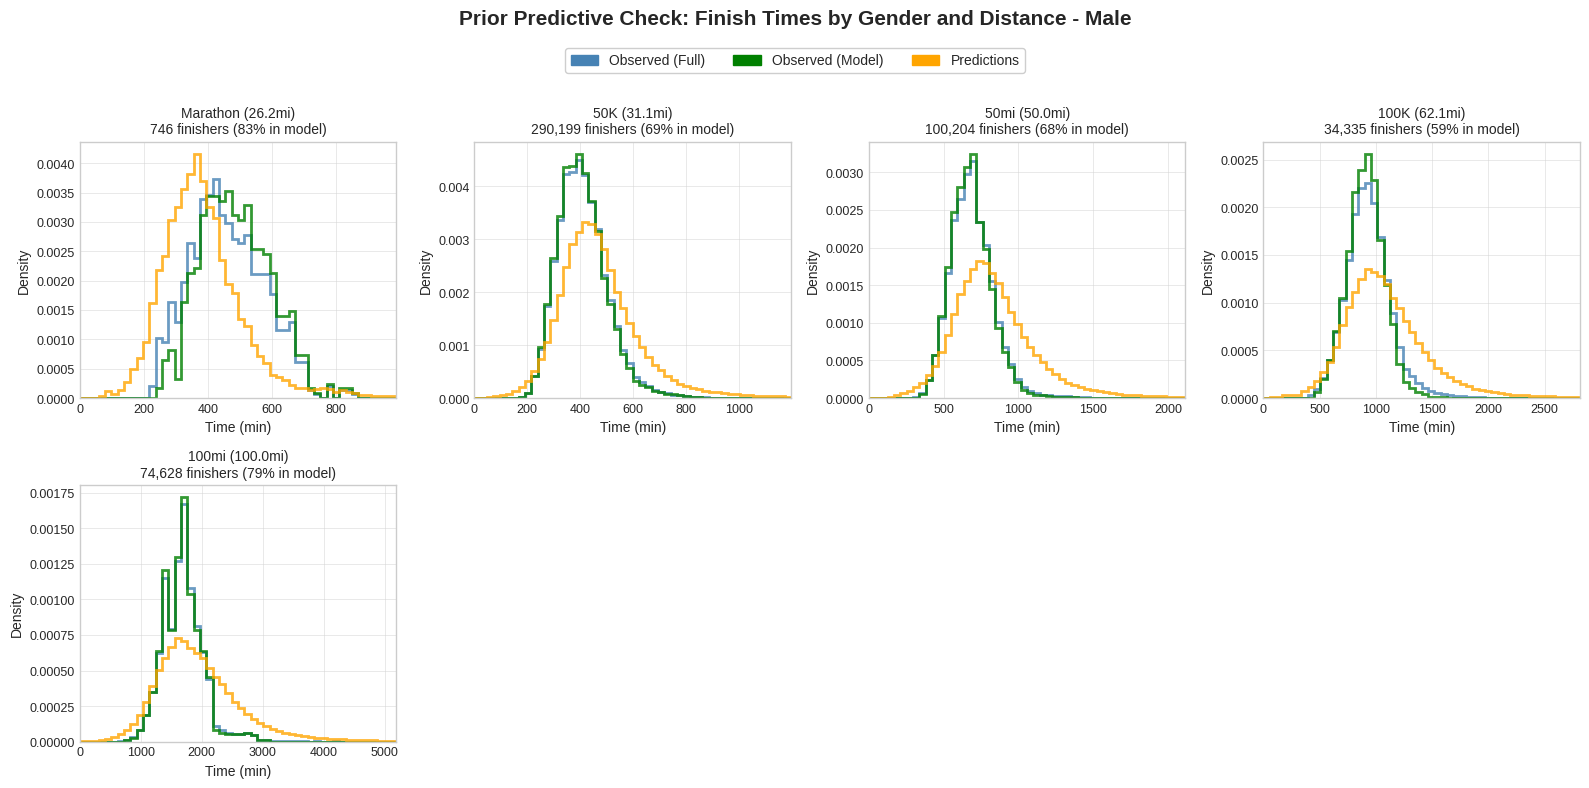

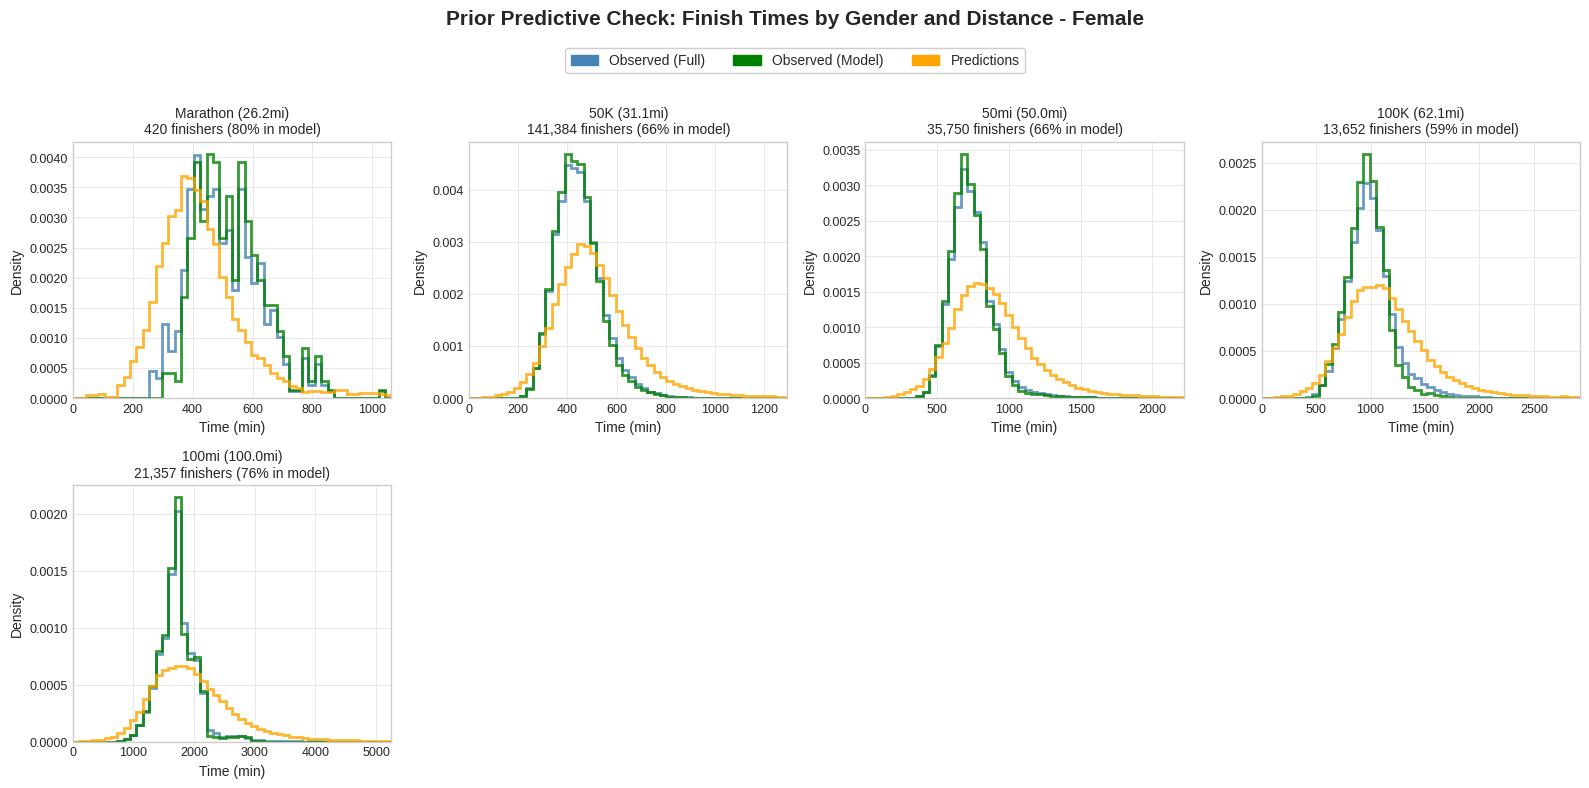

In [16]:
# Posterior Predictive Check Helper Functions

def plot_ppc(fig, distances, full_data, model_data, predictions, 
             xlabel, ylabel, title_template, colors=None, xlim=None):
    """
    Generic PPC plotting function for 2x4 grid of distance facets.
    
    Creates a 2x4 grid showing observed vs predicted distributions across distances.
    Works for both continuous (finish times) and binary (DNF rates) outcomes.
    
    Parameters
    ----------
    fig : matplotlib.figure.Figure
        Figure object to plot on
    distances : list of tuple
        Distance specifications as (value, label, tolerance) tuples
    full_data : dict
        Full observed data with keys determined by data type
    model_data : dict
        Model subset data with keys determined by data type
    predictions : dict
        Predicted values indexed by distance index
    xlabel : str
        Label for x-axis
    ylabel : str
        Label for y-axis
    title_template : callable
        Function taking (name, dist_value, n_full, n_model) -> title string
    colors : dict, optional
        Color mapping for distributions. Default: steelblue, green, orange
    xlim : tuple, optional
        Fixed x-axis limits as (min, max). If None, auto-determined per subplot
    """
    if colors is None:
        colors = {
            'Observed (Full)': 'steelblue',
            'Observed (Model)': 'green',
            'Predictions': 'orange'
        }
    
    # Create 2x4 grid of subplots
    axes = fig.subplots(2, 4)
    axes = axes.flatten()
    
    # Plot each distance
    for dist_idx, distance_tuple in enumerate(distances):
        dist_value, name, tolerance = distance_tuple
        ax = axes[dist_idx]
        ax.set_facecolor('white')
        
        # Filter full dataset
        full_filtered = full_data['filter_fn'](full_data, dist_value, tolerance)
        
        # Filter model dataset
        model_filtered = model_data['filter_fn'](model_data, dist_value, tolerance)
        
        # Get predictions
        pred_filtered = predictions.get(dist_idx, np.array([]))
        
        # Determine x-axis limits
        if xlim is None:
            # Auto-determine from data
            all_data = []
            if len(full_filtered) > 0:
                all_data.append(full_filtered)
            if len(model_filtered) > 0:
                all_data.append(model_filtered)
            if len(pred_filtered) > 0:
                all_data.append(pred_filtered)
            
            if all_data:
                all_combined = np.concatenate(all_data)
                x_min = 0 if all_combined.min() >= 0 else all_combined.min()
                x_max = np.percentile(all_combined, 99) * 1.05
                x_range = (x_min, x_max)
            else:
                x_range = None
        else:
            x_range = xlim
        
        # Create bins
        if x_range is not None:
            bins = np.linspace(x_range[0], x_range[1], 51)
        else:
            bins = 50
        
        # Plot distributions
        distributions = {
            'Observed (Full)': full_filtered,
            'Observed (Model)': model_filtered,
            'Predictions': pred_filtered
        }
        
        for dist_name, dist_data in distributions.items():
            if len(dist_data) == 0:
                continue
            color = colors[dist_name]
            ax.hist(dist_data, bins=bins, histtype='step', linewidth=2,
                   density=True, color=color, linestyle='-', alpha=0.8, range=x_range)
        
        # Set limits
        if x_range is not None:
            ax.set_xlim(x_range)
        
        # Labels and title
        ax.set_xlabel(xlabel, fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_title(title_template(name, dist_value, len(full_filtered), len(model_filtered)), 
                    fontsize=10)
        ax.tick_params(labelsize=9)
        ax.grid(True, color='lightgray', alpha=0.7, linewidth=0.5)
    
    # Turn off unused subplots
    for idx in range(len(distances), len(axes)):
        axes[idx].axis('off')


def plot_finish_time_ppc(inference_data, results, model_data, distances, title):
    """
    Plot finish time predictive check by gender.
    
    Creates separate figures for Male and Female showing 8 distance facets
    with observed and predicted finish time distributions.
    
    Parameters
    ----------
    inference_data : arviz.InferenceData
        InferenceData with prior_predictive or posterior_predictive
    results : pd.DataFrame
        Full results dataset
    model_data : pd.DataFrame
        Model subset data
    distances : list of tuple
        Distance specifications
    title : str
        Base title for figures
    
    Returns
    -------
    dict
        Dictionary mapping gender labels to Figure objects
    """
    # Extract finishers and setup
    model_data_finishers = model_data[model_data['finished'] & (model_data['time_ms'] > 0)].copy()
    unique_genders = np.array(['M', 'F'])
    gender_to_idx = {'M': 0, 'F': 1}
    
    # Extract predictive samples - auto-detect prior vs posterior
    if hasattr(inference_data, 'posterior_predictive') and 'finisher_times' in inference_data.posterior_predictive:
        finish_times = inference_data.posterior_predictive["finisher_times"].values
    elif hasattr(inference_data, 'prior_predictive') and 'finisher_times' in inference_data.prior_predictive:
        finish_times = inference_data.prior_predictive["finisher_times"].values
    else:
        raise ValueError("No 'finisher_times' found in prior_predictive or posterior_predictive")
    
    # Flatten predictions
    finish_times_flat = finish_times.reshape(-1, finish_times.shape[-1])
    
    # Organize predictions by gender and distance
    predictions_by_gender = {}
    for gender_idx, gender in enumerate(unique_genders):
        predictions_by_gender[gender_idx] = {}
        
        for dist_idx, distance_tuple in enumerate(distances):
            dist_value, name, tolerance = distance_tuple
            
            # Get samples for this distance and gender
            model_mask = (
                (model_data_finishers['gender'].map(gender_to_idx) == gender_idx) &
                (np.abs(model_data_finishers['distance_miles'] - dist_value) <= tolerance)
            )
            finisher_indices = np.where(model_mask)[0]
            
            if len(finisher_indices) > 0:
                predictions_by_gender[gender_idx][dist_idx] = finish_times_flat[:, finisher_indices].flatten()
            else:
                predictions_by_gender[gender_idx][dist_idx] = np.array([])
    
    # Prepare full and model data
    finishers_full = results[results['finished']].copy()
    full_times = finishers_full['time_ms'].values / 60000  # Convert to minutes
    full_gender_indices = finishers_full['gender'].map(gender_to_idx).values
    full_distances = finishers_full['distance_miles'].values
    
    finishers_model = model_data_finishers.copy()
    model_times = finishers_model['time_ms'].values / 60000
    model_gender_indices = finishers_model['gender'].map(gender_to_idx).values
    model_distances = finishers_model['distance_miles'].values
    
    # Create figures for each gender
    gender_display_names = {'M': 'Male', 'F': 'Female'}
    figures = {}
    
    # Create legend elements
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='steelblue', edgecolor='steelblue', label='Observed (Full)'),
        Patch(facecolor='green', edgecolor='green', label='Observed (Model)'),
        Patch(facecolor='orange', edgecolor='orange', label='Predictions')
    ]
    
    for gender_idx, gender in enumerate(unique_genders):
        fig = plt.figure(figsize=(16, 8))
        fig.patch.set_facecolor('white')
        
        # Prepare data dictionaries for this gender
        full_data = {
            'times': full_times,
            'gender_indices': full_gender_indices,
            'distances': full_distances,
            'gender_idx': gender_idx,
            'filter_fn': lambda data, dist_val, tol: data['times'][
                (data['gender_indices'] == data['gender_idx']) &
                (np.abs(data['distances'] - dist_val) <= tol)
            ]
        }
        
        model_data_dict = {
            'times': model_times,
            'gender_indices': model_gender_indices,
            'distances': model_distances,
            'gender_idx': gender_idx,
            'filter_fn': lambda data, dist_val, tol: data['times'][
                (data['gender_indices'] == data['gender_idx']) &
                (np.abs(data['distances'] - dist_val) <= tol)
            ]
        }
        
        # Title template
        def title_fn(name, dist_val, n_full, n_model):
            model_pct = f" ({100*n_model/n_full:.0f}% in model)" if n_full > 0 and n_model > 0 else ""
            return f'{name} ({dist_val:.1f}mi)\n{n_full:,} finishers{model_pct}'
        
        # Plot using generic function
        plot_ppc(fig, distances, full_data, model_data_dict, predictions_by_gender[gender_idx],
                xlabel='Time (min)', ylabel='Density', title_template=title_fn)
        
        # Add title and legend
        gender_label = gender_display_names[gender]
        fig.suptitle(f'{title} - {gender_label}', fontsize=15, fontweight='bold', y=0.98)
        fig.legend(handles=legend_elements, loc='upper center', ncol=3, fontsize=10,
                  frameon=True, framealpha=0.95, bbox_to_anchor=(0.5, 0.94))
        
        # Reserve space for title and legend
        plt.tight_layout(rect=[0, 0, 1, 0.92])
        
        figures[gender_label] = fig
    
    return figures


figures = plot_finish_time_ppc(
    inference_data=prior_pred,
    results=results,
    model_data=model_data_finishers,
    distances=standard_distances,
    title='Prior Predictive Check: Finish Times by Gender and Distance'
)

# Display both figures
for gender_label, fig in figures.items():
    plt.show()


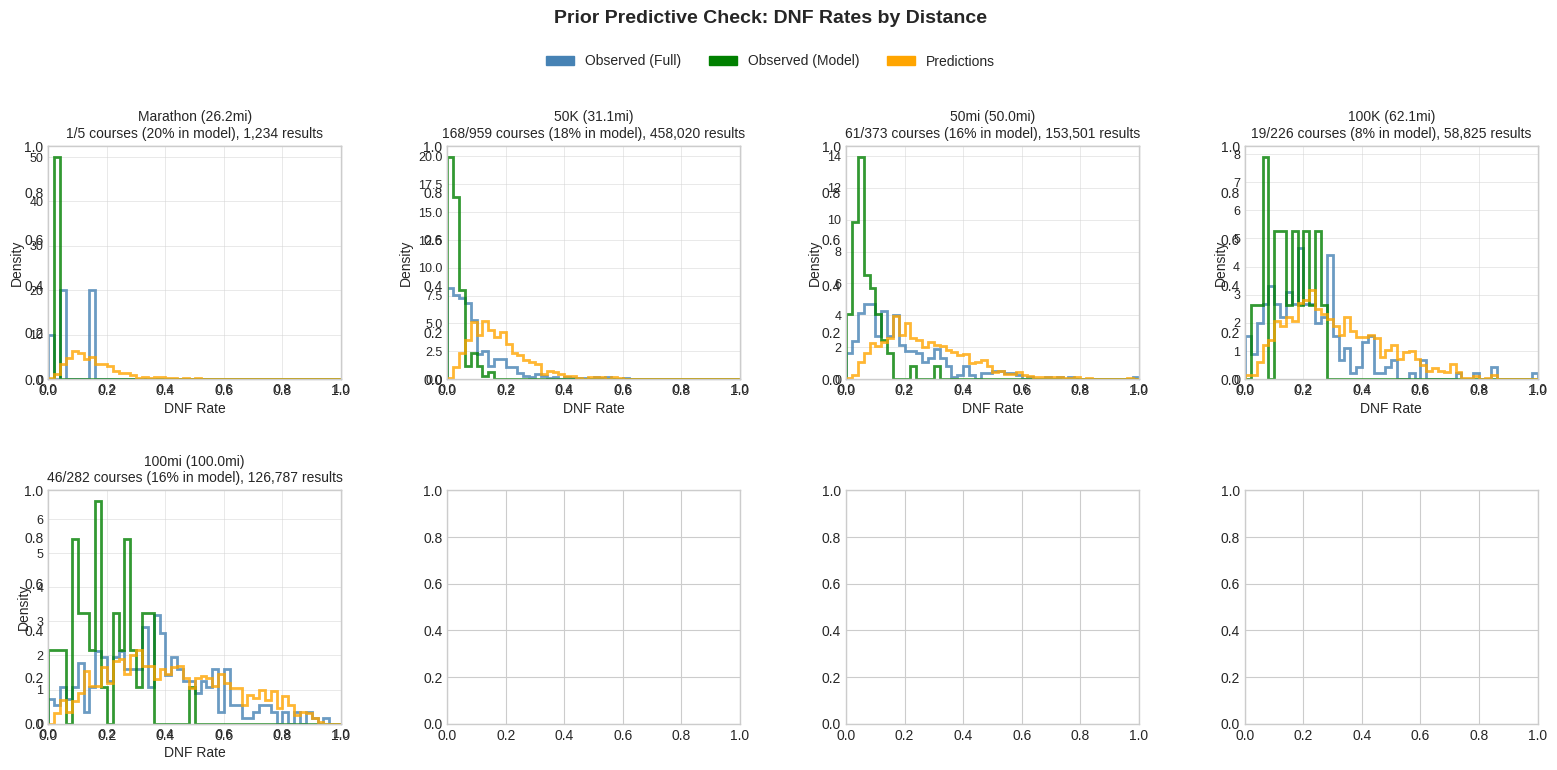

In [17]:
# Prior Predictive Check: DNF Rates by Distance

def plot_dnf_rate_ppc(inference_data, results, model_data, distances, title, reference_distance=26.2):
    """
    Plot predictive check for DNF rates using the generic plot_ppc function.
    
    Creates a single 2x4 grid showing overlaid histograms
    of observed and predicted DNF rate distributions.
    
    Parameters
    ----------
    inference_data : arviz.InferenceData
        InferenceData with prior or posterior samples
    results : pd.DataFrame
        Full results dataset with columns: finished, name, distance_miles
    model_data : pd.DataFrame
        Model subset with columns: finished, name, distance_miles
    distances : list of tuple
        Standard distances for binning (distance_miles, label, tolerance)
    title : str
        Title for the overall figure
    reference_distance : float
        Reference distance for log-space calculations (default: 26.2)
    
    Returns
    -------
    matplotlib.figure.Figure
        The generated figure
    """
    # Derive unique courses and log distance ratios from model_data
    unique_courses = model_data['name'].unique()
    unique_course_distances = np.array([
        model_data[model_data['name'] == course]['distance_miles'].mean()
        for course in unique_courses
    ])
    unique_log_distance_ratios = np.log(unique_course_distances / reference_distance)
    
    # Extract predictive samples - auto-detect prior vs posterior
    if hasattr(inference_data, 'posterior'):
        # Posterior case
        dnf_rate_marathon = inference_data.posterior["dnf_rate_marathon"].values.flatten()
        dnf_distance_multiplier = inference_data.posterior["dnf_distance_multiplier"].values.flatten()
        course_effects_centered = inference_data.posterior["course_effects_centered"].values
        course_effects_centered_flat = course_effects_centered.reshape(-1, course_effects_centered.shape[-2], 
                                                                       course_effects_centered.shape[-1])
    else:
        # Prior case - need to reconstruct course effects
        dnf_rate_marathon = inference_data.prior["dnf_rate_marathon"].values.flatten()
        dnf_distance_multiplier = inference_data.prior["dnf_distance_multiplier"].values.flatten()
        
        dnf_rate_marathon_full = inference_data.prior["dnf_rate_marathon"].values
        dnf_distance_multiplier_full = inference_data.prior["dnf_distance_multiplier"].values
        course_effects_centered = inference_data.prior["course_effects_centered"].values
        
        course_distance_dnf_baseline = (
            dnf_rate_marathon_full[:, :, np.newaxis] +
            dnf_distance_multiplier_full[:, :, np.newaxis] * unique_log_distance_ratios
        )
        
        course_total_dnf_effect = course_distance_dnf_baseline + course_effects_centered[..., 1]
        course_effects_centered_flat = course_total_dnf_effect.reshape(-1, course_total_dnf_effect.shape[-1])
    
    # Create course name to index mapping
    course_name_to_idx = {name: idx for idx, name in enumerate(unique_courses)}
    
    # Get model data courses and distances
    model_course_names_for_pred = model_data['name'].values
    model_race_distances_for_pred = model_data['distance_miles'].values
    
    # Generate predictions for each distance bin
    predictions = {}
    
    for dist_idx, distance_tuple in enumerate(distances):
        dist_value, name, tolerance = distance_tuple
        
        # Filter model data for this distance
        model_distance_mask = np.abs(model_race_distances_for_pred - dist_value) < tolerance
        
        if not model_distance_mask.any():
            predictions[dist_idx] = np.array([])
            continue
        
        # Get courses in this distance bin
        courses_in_bin = model_course_names_for_pred[model_distance_mask]
        unique_courses_in_bin = np.unique(courses_in_bin)
        
        # Map to model indices
        valid_course_indices = []
        for course_name in unique_courses_in_bin:
            if course_name in course_name_to_idx:
                valid_course_indices.append(course_name_to_idx[course_name])
        
        if len(valid_course_indices) > 0:
            # Generate predictions using courses from model data
            n_samples = min(1000, len(dnf_rate_marathon))
            random_draws = np.random.choice(len(dnf_rate_marathon), n_samples, replace=False)
            stratified_courses = np.random.choice(valid_course_indices, size=n_samples, replace=True)
            
            if hasattr(inference_data, 'posterior'):
                # Posterior: use course effects directly
                log_distance_ratio = np.log(dist_value / reference_distance)
                course_deviation_dnf = course_effects_centered_flat[random_draws, stratified_courses, 1]
                
                logit_p_dnf = (
                    dnf_rate_marathon[random_draws] +
                    dnf_distance_multiplier[random_draws] * log_distance_ratio +
                    course_deviation_dnf
                )
            else:
                # Prior: course effects already in course_effects_centered_flat
                logit_p_dnf = course_effects_centered_flat[random_draws, stratified_courses]
            
            p_dnf = 1 / (1 + np.exp(-logit_p_dnf))
            predictions[dist_idx] = p_dnf
        else:
            # Fallback: use baseline without course effects
            n_samples = min(1000, len(dnf_rate_marathon))
            log_distance_ratio = np.log(dist_value / reference_distance)
            logit_p_dnf = (
                dnf_rate_marathon[:n_samples] +
                dnf_distance_multiplier[:n_samples] * log_distance_ratio
            )
            p_dnf = 1 / (1 + np.exp(-logit_p_dnf))
            predictions[dist_idx] = p_dnf
    
    # FULL dataset
    full_did_finish = results['finished'].values
    full_course_names = results['name'].values
    full_race_distances = results['distance_miles'].values
    
    # MODEL DATA subset
    model_did_finish = model_data['finished'].values
    model_course_names = model_data['name'].values
    model_race_distances = model_data['distance_miles'].values
    
    # Prepare data dictionaries with filter_fn for course-based DNF rates
    def compute_course_dnf_rates(data, dist_val, tol):
        """Compute per-course DNF rates for a distance bin."""
        distance_mask = np.abs(data['distances'] - dist_val) < tol
        if not distance_mask.any():
            return np.array([])
        
        courses_in_bin = data['course_names'][distance_mask]
        did_finish_in_bin = data['did_finish'][distance_mask]
        
        course_dnf_rates = []
        for course_name in np.unique(courses_in_bin):
            course_mask = courses_in_bin == course_name
            course_finishes = did_finish_in_bin[course_mask]
            if len(course_finishes) >= 5:
                dnf_rate = 1 - course_finishes.mean()
                course_dnf_rates.append(dnf_rate)
        
        return np.array(course_dnf_rates)
    
    # Full data - store raw distances for counting observations
    full_data = {
        'did_finish': full_did_finish,
        'course_names': full_course_names,
        'distances': full_race_distances,
        'filter_fn': compute_course_dnf_rates
    }
    
    # Model data
    model_data_dict = {
        'did_finish': model_did_finish,
        'course_names': model_course_names,
        'distances': model_race_distances,
        'filter_fn': compute_course_dnf_rates
    }
    
    # Create title template function
    def dnf_title_template(name, dist_value, n_courses_full, n_courses_model):
        # Count observations from full dataset
        distance_mask = np.abs(full_race_distances - dist_value) < 0.5  # Use standard tolerance
        n_obs = distance_mask.sum()
        model_pct = f"{100*n_courses_model/n_courses_full:.0f}%" if n_courses_full > 0 else "0%"
        return (f"{name} ({dist_value:.1f}mi)\n"
                f"{n_courses_model}/{n_courses_full} courses ({model_pct} in model), {n_obs:,} results")
    
    # Create figure
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.patch.set_facecolor('white')
    
    # Use generic plot_ppc
    plot_ppc(
        fig=fig,
        distances=distances,
        full_data=full_data,
        model_data=model_data_dict,
        predictions=predictions,  # Pass the dict directly
        xlabel='DNF Rate',
        ylabel='Density',
        title_template=dnf_title_template,
        xlim=(0, 1)
    )
    
    # Add figure-level title and legend
    handles = [
        plt.matplotlib.patches.Patch(color='steelblue', label='Observed (Full)'),
        plt.matplotlib.patches.Patch(color='green', label='Observed (Model)'),
        plt.matplotlib.patches.Patch(color='orange', label='Predictions')
    ]
    fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 0.94), 
              ncol=3, fontsize=10, frameon=False)
    fig.suptitle(title, fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    
    return fig

fig = plot_dnf_rate_ppc(
    inference_data=prior_pred,
    results=results,
    model_data=kcore_data,
    distances=standard_distances,
    title='Prior Predictive Check: DNF Rates by Distance',
    reference_distance=reference_distance
)
plt.show()


### Geometry Check

Plotting 1000 samples


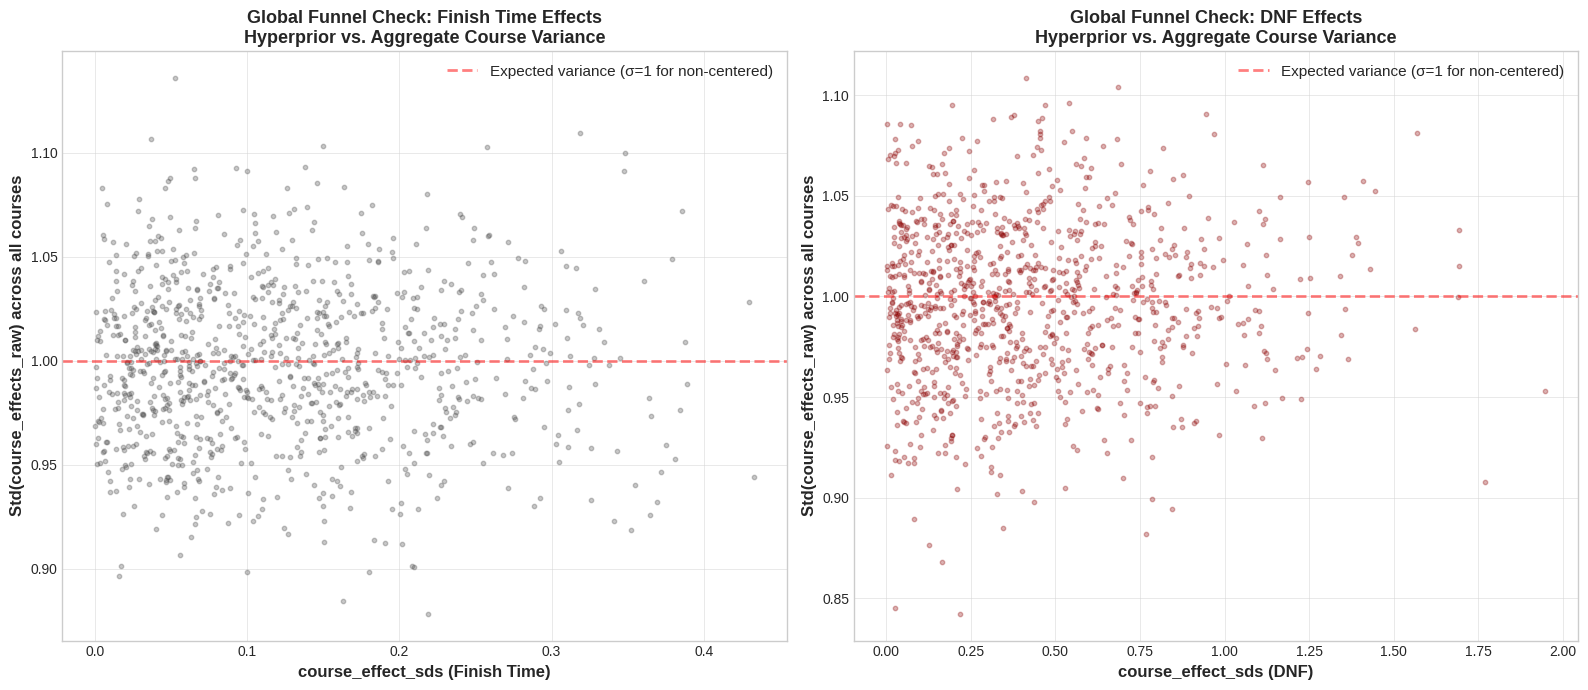

In [18]:
# PRE-SAMPLING GEOMETRY DIAGNOSTIC
# Comprehensive check for sampling issues using ArviZ
# Detects: funnels, high correlations, poor prior specification

# ============================================================================
# GLOBAL FUNNEL CHECK: Hyperprior vs Aggregate Course Variance
# ============================================================================
# Check if the scale parameters (hyperpriors) correlate with the variance of ALL raw course parameters
# This is the RIGHT way to check for funnel geometry in hierarchical models
# This model has 2D correlated course effects: finish_time and dnf

# Extract chol matrix and compute course_effect_sds from it (not stored as Deterministic for performance)
chol_prior_xr = prior_pred.prior["course_chol"]
chol_prior = chol_prior_xr.values

# The chol matrix is in packed form (chain, draw, 3) where the 3 elements are the lower triangle
# For 2x2 matrix: [[a, 0], [b, c]] stored as [a, b, c]
# We need to reshape to (chains*draws, 3) and then extract elements

# Flatten chain and draw dimensions
if chol_prior.ndim == 3:
    # Shape: (chains, draws, 3) -> (chains*draws, 3)
    chol_flat = chol_prior.reshape(-1, 3)
else:
    # Already flat
    chol_flat = chol_prior

# Extract Cholesky elements: [[a, 0], [b, c]]
a = chol_flat[:, 0]  # (0,0) element
b = chol_flat[:, 1]  # (1,0) element  
c = chol_flat[:, 2]  # (1,1) element

# Compute standard deviations from Cholesky
# SD for effect 0 (finish time): a
# SD for effect 1 (DNF): sqrt(b^2 + c^2)
course_effect_sds_flat = np.stack([
    a,  # Finish time SD
    np.sqrt(b**2 + c**2)  # DNF SD
], axis=-1)  # Shape: (samples, 2)

# Get raw course effects
course_effects_raw_prior_xr = prior_pred.prior["course_effects_raw"]  # xarray
course_effects_raw_prior = course_effects_raw_prior_xr.values  # Convert to numpy

# Compute std of raw parameters across ALL courses (for each MCMC draw and effect type)
if course_effects_raw_prior.ndim == 4:
    # Shape: (chains, draws, n_courses, 2) -> compute std across courses -> (chains*draws, 2)
    course_effects_raw_var = course_effects_raw_prior.std(axis=2).reshape(-1, 2)
elif course_effects_raw_prior.ndim == 3:
    # Shape: (samples, n_courses, 2) -> compute std across courses -> (samples, 2)
    course_effects_raw_var = course_effects_raw_prior.std(axis=1)
else:
    raise ValueError(f"Unexpected course_effects_raw_prior shape: {course_effects_raw_prior.shape}")

# Ensure both arrays have the same number of samples
n_samples = min(len(course_effect_sds_flat), len(course_effects_raw_var))
course_effect_sds_flat = course_effect_sds_flat[:n_samples]
course_effects_raw_var = course_effects_raw_var[:n_samples]

print(f"Plotting {n_samples} samples")

# Create 2 subplots: one for finish time effects, one for DNF effects
fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='white')

effect_names = ['Finish Time', 'DNF']
colors = ['#4a4a4a', '#8B0000']

for idx, (effect_name, color) in enumerate(zip(effect_names, colors)):
    ax = axes[idx]
    ax.set_facecolor('white')
    
    ax.scatter(course_effect_sds_flat[:, idx], course_effects_raw_var[:, idx],
              alpha=0.3, s=10, color=color)
    
    # Add reference line
    ax.axhline(y=1.0, color='red', linestyle='--', linewidth=2, alpha=0.5, 
              label='Expected variance (σ=1 for non-centered)')
    ax.set_xlabel(f'course_effect_sds ({effect_name})', fontsize=12, fontweight='bold')
    ax.set_ylabel(f'Std(course_effects_raw) across all courses', fontsize=12, fontweight='bold')
    ax.set_title(f'Global Funnel Check: {effect_name} Effects\nHyperprior vs. Aggregate Course Variance', 
                fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, color='lightgray', alpha=0.7, linewidth=0.5)

plt.tight_layout()
plt.show()


## MCMC Inference

### Sampling

In [ ]:
TUNE = 500
DRAWS = 1000
TARGET_ACCEPT = 0.95

# cache path
cache_file = f'{subset_dir}/tune{TUNE}_draws{DRAWS}_accept{TARGET_ACCEPT}.nc'

# Hyperparameters to monitor
hyperparam_vars = [
    'pace_marathon', 
    'pace_distance_effect',
    'finish_time_noise',           
    'dnf_rate_marathon', 
    'dnf_distance_multiplier'
]

if os.path.exists(cache_file):
    print(f"Loading cached trace from {cache_file}")
    trace = az.from_netcdf(cache_file)
else:
    # Build start message for both console and notification
    start_message = (
        f"Configuration: tune={TUNE}, draws={DRAWS}, target_accept={TARGET_ACCEPT}\n"
        f"Platform: {PLATFORM_CONFIG}\n"
        f"K-core subset: alpha={alpha}, beta={beta}\n"
        f"Data: total results={len(model_data):,}, courses={n_courses:,}, runners={model_data['participant_id'].nunique():,}"
    )
    
    # Print to console
    print(start_message)
    
    # Send start notification with same message
    notify_mcmc_start(
        model_name="Model 2 (Observed DNFs)",
        message=start_message
    )
    start_time = time.time()

    try:
        with model:
            trace = pm.sample(
                draws=DRAWS,  
                tune=TUNE,   
                chains=4,
                cores=4,
                target_accept=TARGET_ACCEPT,  
                random_seed=37,
                return_inferencedata=True,
                idata_kwargs={'log_likelihood': False},
                nuts_sampler=NUTS_SAMPLER  # Dynamic: blackjax (macOS) or numpyro (Linux)
            )
        
        # Clear JAX cache to prevent memory issues
        jax.clear_caches()
        
        elapsed_time = time.time() - start_time
        
        # Build summary string for both console output and notification
        summary_text = build_mcmc_summary_string(trace, hyperparam_vars)
        
        # Print summary to console
        print("\n" + "="*60)
        print("MCMC SAMPLING COMPLETE")
        print("="*60)
        print(summary_text)
        print("="*60 + "\n")
        
        # Send completion notification with same summary
        notify_mcmc_complete(
            model_name="Model 2 (Observed DNFs)",
            elapsed_time=elapsed_time,
            summary_text=summary_text
        )
        
        # Save trace to cache
        print(f"Saving trace to {cache_file}")
        trace.to_netcdf(cache_file)
        
    except Exception as e:
        notify_mcmc_error( model_name="Model 2 (Observed DNFs)", error_msg=str(e))
        raise

az.summary(trace)


Configuration: tune=500, draws=1000, target_accept=0.95
Platform: Linux + GPU (numpyro, 4 GPU(s), 4 JAX device(s))
K-core subset: alpha=3, beta=233
Data: total results=591,435, courses=327, runners=187,326
Notification sent: MCMC Started


  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

In [ ]:
# Reconstruct hyperparameters that were removed for performance
# Do this immediately after loading trace so hyperparam_vars will work

# The course_chol from LKJCholeskyCov is often not fully saved to trace
# We can reconstruct hyperparameters from the course_effects_centered instead

if 'course_effect_sds' not in trace.posterior or 'course_correlation' not in trace.posterior:
    print("Reconstructing course_effect_sds and course_correlation...")
    
    # Reconstruct from the centered effects using empirical covariance
    effects = trace.posterior['course_effects_centered'].values  # (chains, draws, courses, 2)
    
    n_chains, n_draws, n_courses, _ = effects.shape
    print(f"  course_effects_centered shape: {effects.shape}")
    
    # For each chain/draw, compute the empirical covariance
    course_effect_sds = np.zeros((n_chains, n_draws, 2))
    course_correlation = np.zeros((n_chains, n_draws))
    
    for chain in range(n_chains):
        for draw in range(n_draws):
            # Get effects for this sample: (n_courses, 2)
            sample_effects = effects[chain, draw, :, :]
            
            # Compute covariance
            cov = np.cov(sample_effects.T)  # (2, 2)
            
            # Extract stds and correlation
            course_effect_sds[chain, draw, 0] = np.sqrt(cov[0, 0])
            course_effect_sds[chain, draw, 1] = np.sqrt(cov[1, 1])
            course_correlation[chain, draw] = cov[0, 1] / (np.sqrt(cov[0, 0]) * np.sqrt(cov[1, 1]))
    
    # Add to trace
    import xarray as xr
    
    trace.posterior['course_effect_sds'] = xr.DataArray(
        course_effect_sds,
        dims=['chain', 'draw', 'course_effect_type'],
        coords={
            'chain': trace.posterior.chain,
            'draw': trace.posterior.draw,
            'course_effect_type': ['finish_time_total', 'dnf_total']
        }
    )
    
    trace.posterior['course_correlation'] = xr.DataArray(
        course_correlation,
        dims=['chain', 'draw'],
        coords={'chain': trace.posterior.chain, 'draw': trace.posterior.draw}
    )
    
    print(f"✅ Reconstructed course_effect_sds and course_correlation")
    print(f"   course_effect_sds shape: {course_effect_sds.shape}")
    print(f"   course_correlation shape: {course_correlation.shape}")
else:
    print("✓ course_effect_sds and course_correlation already in trace")

### Traceplot

In [ ]:
# traceplot for hyperparameters
axes = az.plot_trace(trace, var_names=hyperparam_vars, compact=True, figsize=(12, 10))
fig = axes.ravel()[0].figure
fig.patch.set_facecolor('white')
for ax in axes.ravel():
    ax.set_facecolor('white')
    if ax.get_xlabel() or ax.get_ylabel():  # Only add grid to plots with axes
        ax.grid(True, color='lightgray', alpha=0.7, linewidth=0.5)
plt.suptitle('MCMC Traces: Course-Level Difficulty Model Hyperparameters', fontsize=14, fontweight='bold')
plt.tight_layout()

# save traceplot
traceplot_file = f'{subset_dir}/tune{TUNE}_draws{DRAWS}_accept{TARGET_ACCEPT}_traceplot.png'
plt.savefig(traceplot_file, dpi=300, bbox_inches='tight')
print(f"Saved traceplot to {traceplot_file}")

plt.show()

# traceplot for sample of course difficulty parameters
course_coords = list(trace.posterior.coords['course'].values)
sample_course_ids = np.random.choice(course_coords, size=min(20, len(course_coords)), replace=False)

axes = az.plot_trace(
    trace, 
    var_names=['course_effects_centered'],  # Use centered effects (finish + DNF)
    coords={'course': sample_course_ids},
    compact=True, 
    figsize=(12, 20)
)
fig = axes.ravel()[0].figure
fig.patch.set_facecolor('white')
for ax in axes.ravel():
    ax.set_facecolor('white')
    if ax.get_xlabel() or ax.get_ylabel():  # Only add grid to plots with axes
        ax.grid(True, color='lightgray', alpha=0.7, linewidth=0.5)
plt.suptitle('MCMC Traces: Sample Course Effects (Centered)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Posterior Diagnostics

In [ ]:
plot_posterior_diagnostics(trace, hyperparam_vars, subset_dir, TUNE, DRAWS, TARGET_ACCEPT)

### Posterior Predictive Check

In [ ]:
with model:
    post_pred = pm.sample_posterior_predictive(
        trace, 
        random_seed=37,
        progressbar=True
    )

# add posterior predictive to trace
trace.extend(post_pred)

In [ ]:
# Posterior Predictive Check: Finish Times by Gender and Distance
fig = plot_finish_time_ppc(
    inference_data=trace,
    results=results,
    model_data=model_data_finishers,
    distances=standard_distances,
    title='Posterior Predictive Check: Finish Times by Gender and Distance'
)
plt.show()

In [ ]:
# Posterior Predictive Check: DNF Rates by Distance
fig = plot_dnf_rate_ppc(
    inference_data=trace,
    results=results,
    model_data=kcore_data,
    distances=standard_distances,
    title='Posterior Predictive Check: DNF Rates by Distance',
    reference_distance=REFERENCE_DISTANCE
)
plt.show()

### Parameter Visualizations

In [ ]:
# Pace-Distance Curves by Gender
# Extract posterior samples for pace_marathon and pace_distance_effect
pace_marathon_samples = trace.posterior["pace_marathon"].values  # Shape: (chains, draws, n_genders)
pace_distance_effect_samples = trace.posterior["pace_distance_effect"].values  # Shape: (chains, draws, n_genders)

# Create distance range for visualization
distances = np.linspace(5, 100, 200)  # 5 to 100 miles

# Plot both genders on the same figure
fig, ax = plt.subplots(1, 1, figsize=(14, 8), facecolor='white')

# Define colors for each gender
gender_colors = {'M': 'steelblue', 'F': 'pink'}
gender_labels = {'M': 'Male', 'F': 'Female'}

# First pass: calculate all median curves to determine y-limits
all_pace_medians = {}
for gender_idx, gender in enumerate(unique_genders):
    pace_marathon_flat = pace_marathon_samples[:, :, gender_idx].flatten()
    pace_distance_effect_flat = pace_distance_effect_samples[:, :, gender_idx].flatten()
    
    log_pace_curves = []
    for pace_base, dist_effect in zip(pace_marathon_flat, pace_distance_effect_flat):
        log_pace = pace_base + dist_effect * np.log(distances / reference_distance)
        log_pace_curves.append(np.exp(log_pace))
    
    log_pace_curves = np.array(log_pace_curves)
    all_pace_medians[gender] = {
        'median': np.percentile(log_pace_curves, 50, axis=0),
        'p25': np.percentile(log_pace_curves, 25, axis=0),
        'p75': np.percentile(log_pace_curves, 75, axis=0),
    }

# Determine y-limits from all medians
all_median_values = np.concatenate([all_pace_medians[g]['median'] for g in unique_genders])
y_min = all_median_values.min() - 0.5
y_max = all_median_values.max() + 1.0
ax.set_ylim(y_min, y_max)

# Second pass: plot curves and markers
for gender_idx, gender in enumerate(unique_genders):
    pace_data = all_pace_medians[gender]
    pace_median = pace_data['median']
    pace_25 = pace_data['p25']
    pace_75 = pace_data['p75']
    
    color = gender_colors[gender]
    
    # Fill between for uncertainty
    ax.fill_between(distances, pace_25, pace_75, alpha=0.25, color=color)
    
    # Median curve
    ax.plot(distances, pace_median, color=color, linewidth=2.5)
    
    # Add markers and annotations for ALL standard distances
    for dist_value, name, _ in standard_distances:
        # Find closest index in distances array
        idx = np.argmin(np.abs(distances - dist_value))
        pace = pace_median[idx]
        
        # Plot marker
        ax.plot(dist_value, pace, 'o', color=color, markersize=6, zorder=5, alpha=0.8)
        
        # Label with pace value (offset vertically by gender to avoid overlap)
        y_offset = 0.15 if gender == 'M' else -0.4
        label_text = f"{pace:.1f}"
        ax.text(dist_value, pace + y_offset, label_text, fontsize=7, 
                ha='center', va='bottom' if gender == 'M' else 'top', 
                fontweight='bold', color=color)

# Add distance labels at the top
y_label_position = y_max - 0.2  # Fixed offset from top
for dist_value, name, _ in standard_distances:
    ax.axvline(x=dist_value, color='gray', linestyle=':', alpha=0.3, linewidth=1)
    ax.text(dist_value, y_label_position, name, fontsize=8, 
            ha='center', va='top', rotation=0, alpha=0.6)

ax.set_xlabel('Distance (miles)', fontsize=13, fontweight='bold')
ax.set_ylabel('Pace (min/mile)', fontsize=13, fontweight='bold')
ax.set_title('Learned Pace-Distance Curves by Gender (Population Average)', 
             fontsize=15, fontweight='bold', pad=20)
ax.set_facecolor('white')
ax.grid(True, color='lightgray', alpha=0.7, linewidth=0.5, linestyle='--')
ax.set_xlim(5, 100)

plt.tight_layout()
plt.show()


In [ ]:
# Plot learned DNF rate as a function of course distance
# This shows the distance baseline (without course-specific effects)

# Get the learned distance baseline DNF effects from the posterior
# This is dnf_rate_marathon + dnf_distance_multiplier * log(distance / marathon_distance)
dnf_rate_marathon_samples = trace.posterior["dnf_rate_marathon"].values.flatten()
dnf_distance_multiplier_samples = trace.posterior["dnf_distance_multiplier"].values.flatten()

# Create a range of distances to plot
distance_range_miles = np.linspace(10, 100, 200)
log_distance_ratios = np.log(distance_range_miles / reference_distance)

# Calculate DNF logit for each distance (across all posterior samples)
dnf_logit_curves = dnf_rate_marathon_samples[:, np.newaxis] + \
                   dnf_distance_multiplier_samples[:, np.newaxis] * log_distance_ratios

# Convert from logit to probability
def logit_to_prob(logit):
    return 1 / (1 + np.exp(-logit))

dnf_prob_curves = logit_to_prob(dnf_logit_curves)

# Calculate median and credible intervals
dnf_prob_median = np.median(dnf_prob_curves, axis=0)
dnf_prob_q05 = np.percentile(dnf_prob_curves, 5, axis=0)
dnf_prob_q95 = np.percentile(dnf_prob_curves, 95, axis=0)

# Create the plot
fig, ax = plt.subplots(figsize=(12, 7))

# Plot the median curve
ax.plot(distance_range_miles, dnf_prob_median * 100, 
        linewidth=3, color="#000000", label='Median learned DNF rate')

# Plot the credible interval
ax.fill_between(distance_range_miles, dnf_prob_q05 * 100, dnf_prob_q95 * 100,
                alpha=0.3, color="#000000", label='90% Credible Interval')

# Add vertical lines for standard distances
for dist_miles, dist_label, _ in standard_distances:
    if 10 <= dist_miles <= 100:
        ax.axvline(dist_miles, color='gray', linestyle='--', alpha=0.3, linewidth=1)
        # Calculate DNF rate at this distance
        log_ratio = np.log(dist_miles / reference_distance)
        dnf_logit_at_dist = dnf_rate_marathon_samples + dnf_distance_multiplier_samples * log_ratio
        dnf_prob_at_dist = logit_to_prob(dnf_logit_at_dist)
        median_dnf = np.median(dnf_prob_at_dist) * 100
        ax.text(dist_miles, median_dnf + 2, dist_label, 
               ha='center', va='bottom', fontsize=9, color='gray')

ax.set_xlabel('Race Distance (miles)', fontsize=12, fontweight='bold')
ax.set_ylabel('DNF Rate (%)', fontsize=12, fontweight='bold')
ax.set_title('Learned DNF Rate as a Function of Distance\n(Distance Baseline Effect Only)', 
             fontsize=14, fontweight='bold')
ax.grid(alpha=0.3, linestyle=':')
ax.legend(loc='upper left', fontsize=11)
ax.set_xlim(10, 100)
ax.set_ylim(0, max(dnf_prob_q95 * 100) + 5)

plt.tight_layout()
plt.show()

In [ ]:
# NEW DIAGNOSTIC: Correlation Posterior
# Visualize the learned correlation between finish time and DNF course effects
course_correlation_posterior = trace.posterior['course_correlation'].values.flatten()

# Compute HDI
hdi_94 = az.hdi(trace, var_names=['course_correlation'], hdi_prob=0.94)
hdi_lower = float(hdi_94['course_correlation'].values[0])
hdi_upper = float(hdi_94['course_correlation'].values[1])

# Compute summary statistics
mean_corr = course_correlation_posterior.mean()
median_corr = np.median(course_correlation_posterior)

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(12, 6), facecolor='white')

# Plot posterior distribution
ax.hist(course_correlation_posterior, bins=60, alpha=0.7, color='#666666', density=True, label='Posterior')

# Add vertical lines for key statistics
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Independence', alpha=0.7)
ax.axvline(x=mean_corr, color='black', linestyle='-', linewidth=2.5, label=f'Mean ({mean_corr:+.3f})')
ax.axvline(x=median_corr, color='darkblue', linestyle='-', linewidth=2, label=f'Median ({median_corr:+.3f})', alpha=0.8)

# Shade HDI region
ax.axvspan(hdi_lower, hdi_upper, alpha=0.2, color='green', label=f'94% HDI [{hdi_lower:+.3f}, {hdi_upper:+.3f}]')

# Formatting
ax.set_xlabel('Correlation Coefficient', fontsize=13, fontweight='bold')
ax.set_ylabel('Density', fontsize=13, fontweight='bold')
ax.set_title('Posterior: Correlation between Course Finish Time and DNF Effects\n(Measures Selection Bias Strength)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.set_facecolor('white')
ax.grid(True, color='lightgray', alpha=0.7, linewidth=0.5, axis='y')
ax.set_xlim(-1, 1)

# Add interpretation text box
# NOTE: After fix, NEGATIVE correlation = harder courses → MORE DNFs (selection bias)
# This is because logit_p_dnf is now correctly negated in the model
if mean_corr < -0.2:
    interp = "✅ NEGATIVE CORRELATION DETECTED\nHarder courses → More DNFs (Selection Bias)"
    box_color = 'lightcoral'
elif mean_corr > 0.2:
    interp = "⚠️ POSITIVE CORRELATION\nHarder courses → Fewer DNFs? (Unexpected)"
    box_color = 'lightyellow'
else:
    interp = "⚪ WEAK/NO CORRELATION\nFinish time and DNF effects are independent"
    box_color = 'lightgray'

ax.text(0.98, 0.97, interp, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor=box_color, alpha=0.8))

plt.tight_layout()
plt.show()

### Compute Derived Quantities

Since we removed `pm.Deterministic` for performance (15-25% speedup), we need to manually compute the total effects from fundamental parameters + data arrays.

In [ ]:
# Reconstruct course total effects from fundamental parameters + data arrays
# These were removed as Deterministic variables for MCMC performance optimization

# Extract fundamental parameters from posterior
pace_marathon_post = trace.posterior['pace_marathon']  # Shape: (chains, draws, n_genders)
pace_distance_effect_post = trace.posterior['pace_distance_effect']  # Shape: (chains, draws, n_genders)
dnf_rate_marathon_post = trace.posterior['dnf_rate_marathon']  # Shape: (chains, draws)
dnf_distance_multiplier_post = trace.posterior['dnf_distance_multiplier']  # Shape: (chains, draws)
course_effects_centered_post = trace.posterior['course_effects_centered']  # Shape: (chains, draws, n_courses, 2)

# Compute population averages (these were intermediate variables in model, not saved to trace)
pace_marathon_avg_post = pace_marathon_post.mean(dim='gender')  # Shape: (chains, draws)
pace_distance_effect_avg_post = pace_distance_effect_post.mean(dim='gender')  # Shape: (chains, draws)

# Reconstruct course_distance_finish_baseline from fundamentals + data
# Need to expand dims for broadcasting: (chains, draws) + (chains, draws) * (n_courses,)
# Result shape: (chains, draws, n_courses)
course_distance_finish_baseline_post = (
    pace_marathon_avg_post.values[..., np.newaxis] + 
    pace_distance_effect_avg_post.values[..., np.newaxis] * unique_log_distance_ratios
)

# Reconstruct course_distance_dnf_baseline from fundamentals + data
# Shape broadcasting: (chains, draws) + (chains, draws) * (n_courses,) -> (chains, draws, n_courses)
course_distance_dnf_baseline_post = (
    dnf_rate_marathon_post.values[..., np.newaxis] + 
    dnf_distance_multiplier_post.values[..., np.newaxis] * unique_log_distance_ratios
)

# Compute total finish effect: baseline + centered_effect[0] (no clipping)
import xarray as xr
course_total_finish_effect_post = (
    course_distance_finish_baseline_post + 
    course_effects_centered_post.sel(course_effect_type='finish_time_total').values
)

# Compute total DNF effect: baseline + centered_effect[1]
course_total_dnf_effect_post = (
    course_distance_dnf_baseline_post + 
    course_effects_centered_post.sel(course_effect_type='dnf_total').values
)

# Extract quantiles for plotting (flattening chains and draws)
# Reshape to (chains*draws, n_courses) for quantile computation
finish_flat = course_total_finish_effect_post.reshape(-1, course_total_finish_effect_post.shape[-1])
dnf_flat = course_total_dnf_effect_post.reshape(-1, course_total_dnf_effect_post.shape[-1])

mcmc_finish_effect_medians = np.median(finish_flat, axis=0)
mcmc_finish_effect_q05 = np.percentile(finish_flat, 5, axis=0)
mcmc_finish_effect_q25 = np.percentile(finish_flat, 25, axis=0)
mcmc_finish_effect_q75 = np.percentile(finish_flat, 75, axis=0)
mcmc_finish_effect_q95 = np.percentile(finish_flat, 95, axis=0)

mcmc_dnf_effect_medians = np.median(dnf_flat, axis=0)
mcmc_dnf_effect_q05 = np.percentile(dnf_flat, 5, axis=0)
mcmc_dnf_effect_q25 = np.percentile(dnf_flat, 25, axis=0)
mcmc_dnf_effect_q75 = np.percentile(dnf_flat, 75, axis=0)
mcmc_dnf_effect_q95 = np.percentile(dnf_flat, 95, axis=0)

# Also create flattened samples for DNF rate calculations and bias estimation
dnf_rate_marathon_samples = trace.posterior["dnf_rate_marathon"].values.flatten()
dnf_distance_multiplier_samples = trace.posterior["dnf_distance_multiplier"].values.flatten()
correlation_samples = trace.posterior["course_correlation"].values.flatten()

print("✅ Reconstructed course total effects from fundamental parameters")
print(f"   course_total_finish_effect: shape {course_total_finish_effect_post.shape}")
print(f"   course_total_dnf_effect: shape {course_total_dnf_effect_post.shape}")
print(f"   Extracted quantiles for {len(mcmc_finish_effect_medians):,} courses")
print(f"   correlation_samples: {len(correlation_samples):,} samples")

In [ ]:
# Plot finish time bias as a continuous function of distance

# Create distance range
distance_range_miles = np.linspace(10, 100, 200)

# Calculate DNF rate and bias for each distance across all posterior samples
log_ratios = np.log(distance_range_miles / reference_distance)

# Calculate DNF probabilities for each distance
dnf_logit_curves = dnf_rate_marathon_samples[:, np.newaxis] + \
                   dnf_distance_multiplier_samples[:, np.newaxis] * log_ratios
dnf_prob_curves = 1 / (1 + np.exp(-dnf_logit_curves))

# Calculate bias as DNF_rate * correlation (simple heuristic)
# Bias represents the percentage by which observed finish times are faster
bias_curves = dnf_prob_curves * correlation_samples[:, np.newaxis] * 100

# Calculate median and credible intervals
bias_median = np.median(bias_curves, axis=0)
bias_q05 = np.percentile(bias_curves, 5, axis=0)
bias_q95 = np.percentile(bias_curves, 95, axis=0)

# Calculate median correlation for reporting
median_correlation = np.median(correlation_samples)

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6), facecolor='white')

# Plot credible interval in light gray
ax.fill_between(distance_range_miles, bias_q05, bias_q95, 
                alpha=0.3, color='#4a4a4a', label='90% Credible Interval')

# Plot median curve in dark gray
ax.plot(distance_range_miles, bias_median, 
        linewidth=2.5, color='#2a2a2a', label='Median bias')

# Add vertical lines for standard distances
for dist_miles, dist_label, _ in standard_distances:
    if 10 <= dist_miles <= 100:
        ax.axvline(dist_miles, color='gray', linestyle='--', alpha=0.3, linewidth=0.8)
        # Add label at top
        y_pos = ax.get_ylim()[1] * 0.95
        ax.text(dist_miles, y_pos, dist_label, 
                ha='center', va='top', fontsize=9, color='gray')

ax.set_xlabel('Race Distance (miles)', fontsize=12)
ax.set_ylabel('Finish Time Bias (%)', fontsize=12)
ax.set_title('Finish Time Bias Due to DNF Exclusion\n(Observed times faster than if all runners finished)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.set_facecolor('white')
ax.grid(True, color='lightgray', alpha=0.7, linewidth=0.5)
ax.set_xlim(10, 100)

plt.tight_layout()
plt.show()

print(f"Median correlation: {median_correlation:.3f}")
print(f"Bias at 100mi: {bias_median[-1]:.2f}% (median), [{bias_q05[-1]:.2f}%, {bias_q95[-1]:.2f}%]")

## MAP Inference

Extend inference to the full dataset using learned hyperparameters from k-core MCMC.

The k-core subsetting approach provides high-quality estimates of **population-level hyperparameters** (`pace_marathon`, `pace_distance_effect`, `course_finish_time_multiplier_std`, `finish_time_noise`, `dnf_rate_marathon`, `dnf_distance_multiplier`, `course_dnf_multiplier_std`) by focusing on densely-connected runners and courses. However, many courses appear only in the sparse closure (runners or courses with few observations). 

We use a **two-stage strategy**:
1. **MCMC on k-core**: Learn hyperparameters from dense subgraph (already completed above)
2. **MAP on full dataset**: Fix hyperparameters and estimate only course-level parameters for all courses

This approach is efficient because:
- Hyperparameters generalize from dense core to sparse closure
- Course multipliers are entity-specific adjustments (don't need full posterior)
- MAP optimization is fast (seconds/minutes vs. hours for full MCMC)

### Data Preparation

In [ ]:
# Extract posterior medians from k-core MCMC trace
# These hyperparameters will be FIXED in the MAP model
pace_marathon_fixed = trace.posterior["pace_marathon"].median(dim=["chain", "draw"]).values
pace_distance_effect_fixed = trace.posterior["pace_distance_effect"].median(dim=["chain", "draw"]).values

# Extract course effect standard deviations and correlation from chol matrix
# (These were removed as pm.Deterministic for MCMC performance)
chol_flat = trace.posterior["course_chol"].median(dim=["chain", "draw"]).values
# Cholesky is stored as flattened lower triangular: [L[0,0], L[1,0], L[1,1]]
# Reconstruct the 2x2 matrix: L = [[a, 0], [b, c]]
a, b, c = chol_flat
chol_fixed = np.array([[a, 0], [b, c]])

# Covariance: C = L @ L.T = [[a^2, ab], [ab, b^2 + c^2]]
# Stds: [a, sqrt(b^2 + c^2)], Correlation: b / sqrt(a^2 * (b^2 + c^2))
course_effect_sds_fixed = np.array([
    chol_fixed[0, 0],  # Finish time SD
    np.sqrt(chol_fixed[1, 0]**2 + chol_fixed[1, 1]**2)  # DNF SD
])
course_correlation_fixed = float(
    chol_fixed[1, 0] / (chol_fixed[0, 0] * course_effect_sds_fixed[1])
)

# DNF model hyperparameters
dnf_rate_marathon_fixed = float(
    trace.posterior["dnf_rate_marathon"].median(dim=["chain", "draw"]).values
)
dnf_distance_multiplier_fixed = float(
    trace.posterior["dnf_distance_multiplier"].median(dim=["chain", "draw"]).values
)

# Finish time noise is fixed in the model (not estimated)
finish_time_noise_fixed = np.array([sigma_finish_time_noise, sigma_finish_time_noise])

print("Fixed hyperparameters from k-core MCMC:")
print("=" * 60)
print(f"Finish Time Model:")
print(f"  pace_marathon (M, F):                    [{pace_marathon_fixed[0]:.4f}, {pace_marathon_fixed[1]:.4f}]")
print(f"  pace_distance_effect (M, F):             [{pace_distance_effect_fixed[0]:.4f}, {pace_distance_effect_fixed[1]:.4f}]")
print(f"  finish_time_noise (M, F):                [{finish_time_noise_fixed[0]:.4f}, {finish_time_noise_fixed[1]:.4f}] (fixed)")
print(f"\nDNF Model:")
print(f"  dnf_rate_marathon:                       {dnf_rate_marathon_fixed:.4f}")
print(f"  dnf_distance_multiplier:                 {dnf_distance_multiplier_fixed:.4f}")
print(f"\nCorrelated Course Effects:")
print(f"  course_effect_sds [finish, dnf]:         [{course_effect_sds_fixed[0]:.4f}, {course_effect_sds_fixed[1]:.4f}]")
print(f"  course_correlation:                      {course_correlation_fixed:.4f}")
print("=" * 60)

### Specification

Build a PyMC model with the same structure as the MCMC model, but with hyperparameters fixed to their posterior medians. Only course-level parameters will be estimated.

In [ ]:
# Prepare full dataset for MAP estimation
results_full = filter_races_with_dnfs(results)
finishers_full = results_full[results_full['finished'] & (results_full['time_ms'] > 0)].copy()

# Create categorical indices for full dataset
unique_courses_full = results_full['name'].unique()
course_to_idx_full = {course: idx for idx, course in enumerate(unique_courses_full)}
gender_to_idx_full = {'M': 0, 'F': 1}

# Finish time model data (finishers only)
course_indices_finishers_full = finishers_full['name'].map(course_to_idx_full).values
gender_indices_finishers_full = finishers_full['gender'].map(gender_to_idx_full).values
distances_finishers_full = finishers_full['distance_miles'].values
observed_times_finishers_full = finishers_full['time_ms'].values / 60_000  # Convert to minutes

# DNF model data (all results)
course_indices_results_full = results_full['name'].map(course_to_idx_full).values
distances_results_full = results_full['distance_miles'].values
did_finish_full = results_full['finished'].values.astype(int)

n_courses_full = len(unique_courses_full)

# PERFORMANCE OPTIMIZATION: Pre-compute course distances BEFORE model definition
# This prevents Python loops inside the PyMC model context (same as MCMC model)
unique_course_distances_full = np.array([
    distances_finishers_full[course_indices_finishers_full == i].mean() 
    if (course_indices_finishers_full == i).any()
    else (distances_results_full[course_indices_results_full == i].mean()
          if (course_indices_results_full == i).any()
          else REFERENCE_DISTANCE)
    for i in range(n_courses_full)
])
unique_log_distance_ratios_full = np.log(unique_course_distances_full / REFERENCE_DISTANCE)

print(f"Full dataset prepared for MAP estimation:")
print(f"  Total courses: {n_courses_full:,}")
print(f"  K-core courses (for comparison): {n_courses:,}")
print(f"  Total results (finishers + DNFs): {len(did_finish_full):,}")
print(f"  Finisher observations: {len(observed_times_finishers_full):,}")

In [ ]:
# Build MAP model with fixed hyperparameters from k-core MCMC posterior
# Construct fixed Cholesky matrix from MCMC medians
corr_matrix = np.array([
    [1.0, course_correlation_fixed],
    [course_correlation_fixed, 1.0]
])
std_diag = np.diag(course_effect_sds_fixed)
cov_matrix = std_diag @ corr_matrix @ std_diag
chol_fixed = np.linalg.cholesky(cov_matrix)

# Build model with fixed hyperparameters
model_map = define_model(
    results_full,
    fixed_params={
        'pace_marathon': pace_marathon_fixed,
        'pace_distance_effect': pace_distance_effect_fixed,
        'dnf_rate_marathon': dnf_rate_marathon_fixed,
        'dnf_distance_multiplier': dnf_distance_multiplier_fixed,
        'chol': chol_fixed
    }
)

# Visualize model structure showing fixed vs free parameters
graph = pm.model_to_graphviz(model_map)
graph

### Estimation

In [ ]:
# Define cache path for MAP results
map_cache_file = f'{subset_dir}/map_full_dataset.nc'

if os.path.exists(map_cache_file):
    print(f"✅ Loading cached MAP estimate from {map_cache_file}")
    map_trace = az.from_netcdf(map_cache_file)
    print(f"   Loaded {len(map_trace.posterior.coords['course']):,} course effects")
else:
    print("🚀 Running MAP estimation on full dataset...")
    print(f"   Fixed hyperparameters from k-core MCMC (8 values)")
    print(f"   Estimating course_effects_raw for {n_courses_full:,} courses (2 effects each)")
    print(f"   Total free parameters: {n_courses_full * 2:,}")
    
    # Initialize course effects from k-core MCMC estimates
    print("\n📊 Initializing course effects from k-core MCMC...")
    mcmc_courses = np.array(trace.posterior.coords['course'].values)
    mcmc_course_effects_raw = trace.posterior['course_effects_raw'].median(dim=['chain', 'draw']).values
    
    # Create initialization array: zeros for non-k-core, MCMC estimates for k-core
    init_course_effects_raw = np.zeros((n_courses_full, 2))
    n_initialized = 0
    
    for i, course_name in enumerate(unique_courses_full):
        if course_name in mcmc_courses:
            mcmc_idx = np.where(mcmc_courses == course_name)[0][0]
            init_course_effects_raw[i, :] = mcmc_course_effects_raw[mcmc_idx, :]
            n_initialized += 1
    
    print(f"   Initialized {n_initialized:,} k-core courses from MCMC posteriors")
    print(f"   Initialized {n_courses_full - n_initialized:,} non-k-core courses to prior mean (0)")
    print()
    
    start_time = time.time()
    
    with model_map:
        map_estimate = pm.find_MAP(
            method='L-BFGS-B',
            start={'course_effects_raw': init_course_effects_raw},
            progressbar=True
        )
    
    elapsed_time = time.time() - start_time
    print(f"\n✅ MAP estimation completed in {elapsed_time:.2f} seconds")
    print(f"   ({elapsed_time / 60:.1f} minutes)")
    
    # Reconstruct total effects from fundamentals (MAP doesn't return Deterministic variables)
    pace_marathon_avg_map = pace_marathon_fixed.mean()
    pace_distance_effect_avg_map = pace_distance_effect_fixed.mean()
    
    course_distance_finish_baseline_map = (
        pace_marathon_avg_map + 
        pace_distance_effect_avg_map * unique_log_distance_ratios_full
    )
    
    course_distance_dnf_baseline_map = (
        dnf_rate_marathon_fixed + 
        dnf_distance_multiplier_fixed * unique_log_distance_ratios_full
    )
    
    course_total_finish_effect_map = (
        course_distance_finish_baseline_map + 
        map_estimate['course_effects_centered'][:, 0]
    )
    
    course_total_dnf_effect_map = (
        course_distance_dnf_baseline_map + 
        map_estimate['course_effects_centered'][:, 1]
    )
    
    # Convert MAP point estimate to InferenceData format for consistency
    # Create a single-draw posterior (shape: [1 chain, 1 draw, ...])
    map_trace = az.from_dict(
        posterior={
            # Free parameters
            'course_effects_raw': map_estimate['course_effects_raw'][np.newaxis, np.newaxis, :, :],
            'course_effects_centered': map_estimate['course_effects_centered'][np.newaxis, np.newaxis, :, :],
            'course_total_finish_effect': course_total_finish_effect_map[np.newaxis, np.newaxis, :],
            'course_total_dnf_effect': course_total_dnf_effect_map[np.newaxis, np.newaxis, :],
            # Fixed hyperparameters (for completeness)
            'pace_marathon': pace_marathon_fixed[np.newaxis, np.newaxis, :],
            'pace_distance_effect': pace_distance_effect_fixed[np.newaxis, np.newaxis, :],
            'dnf_rate_marathon': np.array([[dnf_rate_marathon_fixed]]),
            'dnf_distance_multiplier': np.array([[dnf_distance_multiplier_fixed]]),
            'course_effect_sds': course_effect_sds_fixed[np.newaxis, np.newaxis, :],
            'course_correlation': np.array([[course_correlation_fixed]]),
        },
        coords={
            'course': unique_courses_full,
            'gender': unique_genders,
            'course_effect_type': ['finish_time_total', 'dnf_total']
        },
        dims={
            'course_effects_raw': ['course', 'course_effect_type'],
            'course_effects_centered': ['course', 'course_effect_type'],
            'course_total_finish_effect': ['course'],
            'course_total_dnf_effect': ['course'],
            'pace_marathon': ['gender'],
            'pace_distance_effect': ['gender'],
            'course_effect_sds': ['course_effect_type'],
        }
    )
    
    # Save to cache
    map_trace.to_netcdf(map_cache_file)
    print(f"💾 Saved MAP trace to {map_cache_file}")
    
print()
print("MAP estimation summary:")
print(f"  Course effects estimated: {n_courses_full:,}")
print(f"  Finisher observations: {len(observed_times_finishers_full):,}")
print(f"  Total observations (incl. DNFs): {len(did_finish_full):,}")


In [ ]:
# Reconstruct MAP course total effects from fundamental parameters + data arrays
# These were removed as Deterministic variables for MCMC performance optimization

# Extract fundamental parameters from MAP estimate (shape: [1 chain, 1 draw, ...])
pace_marathon_map = map_trace.posterior['pace_marathon'].values[0, 0, :]  # shape: (n_genders,)
pace_distance_effect_map = map_trace.posterior['pace_distance_effect'].values[0, 0, :]  # shape: (n_genders,)
dnf_rate_marathon_map = map_trace.posterior['dnf_rate_marathon'].values[0, 0]  # scalar
dnf_distance_multiplier_map = map_trace.posterior['dnf_distance_multiplier'].values[0, 0]  # scalar
course_effects_centered_map = map_trace.posterior['course_effects_centered'].values[0, 0, :, :]  # shape: (n_courses, 2)

# Get map course names for matching
map_courses = map_trace.posterior.coords['course'].values

# Compute averages for centering (same as in model definition)
pace_marathon_avg_map = (pace_marathon_map[0] + pace_marathon_map[1]) / 2  # Average of M and F
pace_distance_effect_avg_map = (pace_distance_effect_map[0] + pace_distance_effect_map[1]) / 2

# Reconstruct course_distance_finish_baseline from fundamentals + data
# Note: unique_log_distance_ratios_full corresponds to unique_courses_full
course_distance_finish_baseline_map = (
    pace_marathon_avg_map + 
    pace_distance_effect_avg_map * unique_log_distance_ratios_full
)

# Reconstruct course_distance_dnf_baseline from fundamentals + data
course_distance_dnf_baseline_map = (
    dnf_rate_marathon_map + 
    dnf_distance_multiplier_map * unique_log_distance_ratios_full
)

# Compute total finish effect: baseline + centered_effect[0] (no clipping, matches MCMC model)
map_finish_effect_estimates = course_distance_finish_baseline_map + course_effects_centered_map[:, 0]

# Compute total DNF effect: baseline + centered_effect[1]
map_dnf_effect_estimates = course_distance_dnf_baseline_map + course_effects_centered_map[:, 1]

### K-Core Validation

Validate MAP estimates by comparing them to MCMC posteriors for courses in the k-core subset. This checks whether the MAP optimization produces reasonable point estimates that align with the full Bayesian posterior.

In [ ]:
# Match MCMC courses to MAP courses
# The derived quantities were already computed in helper cells above

# Get MCMC course names
mcmc_courses = trace.posterior.coords['course'].values
n_mcmc_courses = len(mcmc_courses)

# Match MCMC courses to MAP courses
map_course_to_idx = {course: idx for idx, course in enumerate(map_courses)}
matched_map_indices = []
matched_mcmc_indices = []

for mcmc_idx, course_name in enumerate(mcmc_courses):
    if course_name in map_course_to_idx:
        matched_map_indices.append(map_course_to_idx[course_name])
        matched_mcmc_indices.append(mcmc_idx)

matched_map_indices = np.array(matched_map_indices)
matched_mcmc_indices = np.array(matched_mcmc_indices)

# Extract matched estimates (using pre-computed arrays from helper cells)
map_matched_finish = map_finish_effect_estimates[matched_map_indices]
map_matched_dnf = map_dnf_effect_estimates[matched_map_indices]

mcmc_matched_finish_medians = mcmc_finish_effect_medians[matched_mcmc_indices]
mcmc_matched_finish_q05 = mcmc_finish_effect_q05[matched_mcmc_indices]
mcmc_matched_finish_q25 = mcmc_finish_effect_q25[matched_mcmc_indices]
mcmc_matched_finish_q75 = mcmc_finish_effect_q75[matched_mcmc_indices]
mcmc_matched_finish_q95 = mcmc_finish_effect_q95[matched_mcmc_indices]

mcmc_matched_dnf_medians = mcmc_dnf_effect_medians[matched_mcmc_indices]
mcmc_matched_dnf_q05 = mcmc_dnf_effect_q05[matched_mcmc_indices]
mcmc_matched_dnf_q25 = mcmc_dnf_effect_q25[matched_mcmc_indices]
mcmc_matched_dnf_q75 = mcmc_dnf_effect_q75[matched_mcmc_indices]
mcmc_matched_dnf_q95 = mcmc_dnf_effect_q95[matched_mcmc_indices]

# Calculate validation metrics
from scipy.stats import pearsonr
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Finish time effect
finish_correlation = pearsonr(map_matched_finish, mcmc_matched_finish_medians)[0]
finish_mae = mean_absolute_error(mcmc_matched_finish_medians, map_matched_finish)
finish_rmse = np.sqrt(mean_squared_error(mcmc_matched_finish_medians, map_matched_finish))

# DNF effect
dnf_correlation = pearsonr(map_matched_dnf, mcmc_matched_dnf_medians)[0]
dnf_mae = mean_absolute_error(mcmc_matched_dnf_medians, map_matched_dnf)
dnf_rmse = np.sqrt(mean_squared_error(mcmc_matched_dnf_medians, map_matched_dnf))

In [ ]:
# K-Core Validation: Scatter plots comparing MAP vs MCMC for matched courses
# Uses the matched indices already computed in previous cell

# Create scatter plots with error bars
fig, (ax_course, ax_runner) = plt.subplots(1, 2, figsize=(14, 6), facecolor='white')

# Finish time effects scatter
for i in range(len(matched_map_indices)):
    # 90% CI (lighter)
    ax_course.plot([map_matched_finish[i], map_matched_finish[i]], 
                   [mcmc_matched_finish_q05[i], mcmc_matched_finish_q95[i]], 
                   color='steelblue', alpha=0.2, linewidth=1)
    # 50% CI (darker)
    ax_course.plot([map_matched_finish[i], map_matched_finish[i]], 
                   [mcmc_matched_finish_q25[i], mcmc_matched_finish_q75[i]], 
                   color='steelblue', alpha=0.4, linewidth=2)

ax_course.scatter(map_matched_finish, mcmc_matched_finish_medians, alpha=0.6, s=20, color='darkblue')
lims_finish = [min(map_matched_finish.min(), mcmc_matched_finish_q05.min()), 
               max(map_matched_finish.max(), mcmc_matched_finish_q95.max())]
ax_course.plot(lims_finish, lims_finish, 'r--', alpha=0.7, linewidth=2, label='Perfect Agreement')
ax_course.set_xlabel('MAP Estimate (log minutes)', fontsize=12, fontweight='bold')
ax_course.set_ylabel('MCMC Posterior Median (log minutes)', fontsize=12, fontweight='bold')
ax_course.set_title('Finish Time Effects: MAP vs MCMC', fontsize=14, fontweight='bold')
ax_course.set_facecolor('white')
ax_course.grid(True, color='lightgray', alpha=0.7, linewidth=0.5)
ax_course.legend()

# DNF effects scatter
for i in range(len(matched_map_indices)):
    # 90% CI (lighter)
    ax_runner.plot([map_matched_dnf[i], map_matched_dnf[i]], 
                   [mcmc_matched_dnf_q05[i], mcmc_matched_dnf_q95[i]], 
                   color='steelblue', alpha=0.2, linewidth=1)
    # 50% CI (darker)
    ax_runner.plot([map_matched_dnf[i], map_matched_dnf[i]], 
                   [mcmc_matched_dnf_q25[i], mcmc_matched_dnf_q75[i]], 
                   color='steelblue', alpha=0.4, linewidth=2)

ax_runner.scatter(map_matched_dnf, mcmc_matched_dnf_medians, alpha=0.6, s=20, color='darkblue')
lims_dnf = [min(map_matched_dnf.min(), mcmc_matched_dnf_q05.min()), 
            max(map_matched_dnf.max(), mcmc_matched_dnf_q95.max())]
ax_runner.plot(lims_dnf, lims_dnf, 'r--', alpha=0.7, linewidth=2, label='Perfect Agreement')
ax_runner.set_xlabel('MAP Estimate (log odds)', fontsize=12, fontweight='bold')
ax_runner.set_ylabel('MCMC Posterior Median (log odds)', fontsize=12, fontweight='bold')
ax_runner.set_title('DNF Effects: MAP vs MCMC', fontsize=14, fontweight='bold')
ax_runner.set_facecolor('white')
ax_runner.grid(True, color='lightgray', alpha=0.7, linewidth=0.5)
ax_runner.legend()

plt.tight_layout()
plt.show()

### Parameter Visualizations

In [ ]:
def plot_course_forest(map_values, mcmc_medians, mcmc_q05, mcmc_q95, 
                       xlabel, title, reference_line=None, 
                       n_show=50, sort_ascending=True):
    """
    Create a forest plot showing top/bottom courses with MAP estimates and MCMC posteriors.
    
    Parameters
    ----------
    map_values : np.ndarray
        MAP estimates for all courses (shape: n_courses)
    mcmc_medians : list or None
        MCMC median values for each selected course (None entries for courses without MCMC)
    mcmc_q05 : list or None
        MCMC 5th percentile for each selected course
    mcmc_q95 : list or None
        MCMC 95th percentile for each selected course
    xlabel : str
        X-axis label
    title : str
        Plot title
    reference_line : float or None
        Value at which to draw a vertical reference line
    n_show : int
        Number of courses to show from top and bottom (default: 50)
    sort_ascending : bool
        If True, sort ascending (lowest first); if False, descending (highest first)
    
    Returns
    -------
    fig, ax : matplotlib figure and axes objects
    """
    from matplotlib.lines import Line2D
    
    # Get course names
    all_course_names = list(map_trace.posterior.coords['course'].values)
    
    # Sort courses by MAP values
    sorted_indices = np.argsort(map_values)
    if not sort_ascending:
        sorted_indices = sorted_indices[::-1]
    
    # Select top and bottom courses
    top_indices = sorted_indices[:n_show]
    bottom_indices = sorted_indices[-n_show:]
    selected_indices = np.concatenate([top_indices, bottom_indices])
    
    # Create figure with white background
    fig, ax = plt.subplots(1, 1, figsize=(10, 20), facecolor='white')
    ax.set_facecolor('white')
    
    # Extract values and names for selected courses
    selected_map_values = map_values[selected_indices]
    selected_names = [all_course_names[i] for i in selected_indices]
    
    # Check which courses are in MCMC trace
    mcmc_set = set(mcmc_courses)
    selected_in_mcmc = [all_course_names[i] in mcmc_set for i in selected_indices]
    
    # Y positions for plotting
    y_positions = np.arange(len(selected_map_values))
    
    # Get MCMC posteriors for courses that have them
    selected_mcmc_medians = []
    selected_mcmc_q05_vals = []
    selected_mcmc_q95_vals = []
    
    for course_name in selected_names:
        if course_name in mcmc_courses:
            idx = np.where(mcmc_courses == course_name)[0][0]
            selected_mcmc_medians.append(mcmc_medians[idx] if mcmc_medians is not None else None)
            selected_mcmc_q05_vals.append(mcmc_q05[idx] if mcmc_q05 is not None else None)
            selected_mcmc_q95_vals.append(mcmc_q95[idx] if mcmc_q95 is not None else None)
        else:
            selected_mcmc_medians.append(None)
            selected_mcmc_q05_vals.append(None)
            selected_mcmc_q95_vals.append(None)
    
    # Plot each course
    for i, (map_val, in_mcmc) in enumerate(zip(selected_map_values, selected_in_mcmc)):
        # Always plot MAP estimate as orange square
        ax.plot(map_val, y_positions[i], 's', color='orange', markersize=6, alpha=0.8, zorder=5)
        
        # If course is in MCMC, add blue circle for MCMC median and 90% CI
        if in_mcmc and selected_mcmc_medians[i] is not None:
            mcmc_median = selected_mcmc_medians[i]
            mcmc_q05_val = selected_mcmc_q05_vals[i]
            mcmc_q95_val = selected_mcmc_q95_vals[i]
            
            # Plot MCMC credible interval
            ax.plot([mcmc_q05_val, mcmc_q95_val], [y_positions[i], y_positions[i]], 
                   color='steelblue', linewidth=1.5, alpha=0.5, zorder=3)
            
            # Plot MCMC median
            ax.plot(mcmc_median, y_positions[i], 'o', color='steelblue', 
                   markersize=5, alpha=0.7, zorder=4)
    
    # Add vertical reference line if specified
    if reference_line is not None:
        ax.axvline(x=reference_line, color='red', linestyle='--', linewidth=1.5, alpha=0.7, 
                  label=f'Reference ({reference_line})')
    
    # Configure axes
    ax.set_yticks(y_positions)
    ax.set_yticklabels([name[:60] for name in selected_names], fontsize=8)
    ax.set_xlabel(xlabel, fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    # Gray grid lines
    ax.grid(axis='x', alpha=0.3, color='gray', linestyle='-', linewidth=0.5)
    
    # Add legend
    legend_elements = [
        Line2D([0], [0], marker='s', color='w', markerfacecolor='orange', markersize=8, label='MAP Estimate'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=8, label='MCMC Median'),
        Line2D([0], [0], color='steelblue', linewidth=2, alpha=0.5, label='MCMC 90% CI'),
    ]
    if reference_line is not None:
        legend_elements.append(
            Line2D([0], [0], color='red', linestyle='--', linewidth=1.5, label=f'Reference ({reference_line})')
        )
    ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
    
    # Add dividing line between top and bottom
    ax.axhline(y=n_show - 0.5, color='red', linestyle='--', linewidth=2, alpha=0.7)
    
    plt.tight_layout()
    return fig, ax

#### Plot 2: Relative Finish Time Multiplier (Course-Specific Deviation)

In [ ]:
# Plot 2: Relative Finish Time Multiplier (course-specific deviation from distance baseline)
# MAP values: exp(course_effects_centered[:, 0])
map_values_plot2 = np.exp(course_effects_centered_map[:, 0])

# MCMC posteriors: exp(course_effects_centered_post[:, :, :, 0])
# Shape: (chains, draws, n_courses, 2) -> select dimension 0 for finish time
mcmc_rel_finish = np.exp(course_effects_centered_post.values[:, :, :, 0])
mcmc_rel_finish_flat = mcmc_rel_finish.reshape(-1, mcmc_rel_finish.shape[-1])

# Compute medians and quantiles
mcmc_rel_finish_medians = np.median(mcmc_rel_finish_flat, axis=0)
mcmc_rel_finish_q05 = np.percentile(mcmc_rel_finish_flat, 5, axis=0)
mcmc_rel_finish_q95 = np.percentile(mcmc_rel_finish_flat, 95, axis=0)

# Reference at 1.0 (multiplicative identity - average course)
plot_course_forest(
    map_values=map_values_plot2,
    mcmc_medians=mcmc_rel_finish_medians,
    mcmc_q05=mcmc_rel_finish_q05,
    mcmc_q95=mcmc_rel_finish_q95,
    xlabel='Pace multiplier (relative to average course at this distance)',
    title='Relative Finish Time Multiplier',
    reference_line=1.0,
    n_show=50,
    sort_ascending=True
)
plt.show()

#### Plot 4: Relative DNF Probability (Course-Specific Deviation)

In [ ]:
# Plot 4: DNF Odds Ratios (AFTER accounting for distance)
# Using exp(distance_baseline + centered_effect) to get full odds ratios
# OR = 1.0 means average DNF rate for that distance
# OR > 1.0 means higher DNF odds (harder course)
# OR < 1.0 means lower DNF odds (easier course)

# MAP values: exp(course_total_dnf_effect)
# course_total_dnf_effect = course_distance_dnf_baseline + course_effects_centered[:, 1]
map_values_plot4 = np.exp(course_distance_dnf_baseline_map + course_effects_centered_map[:, 1])

# MCMC posteriors: exp(course_total_dnf_effect)
# course_total_dnf_effect_post is already a numpy array
mcmc_full_dnf_odds = np.exp(course_total_dnf_effect_post)
mcmc_full_dnf_odds_flat = mcmc_full_dnf_odds.reshape(-1, mcmc_full_dnf_odds.shape[-1])

# Compute medians and quantiles
mcmc_full_dnf_medians = np.median(mcmc_full_dnf_odds_flat, axis=0)
mcmc_full_dnf_q05 = np.percentile(mcmc_full_dnf_odds_flat, 5, axis=0)
mcmc_full_dnf_q95 = np.percentile(mcmc_full_dnf_odds_flat, 95, axis=0)

# Reference at 1.0 (average course at distance)
plot_course_forest(
    map_values=map_values_plot4,
    mcmc_medians=mcmc_full_dnf_medians,
    mcmc_q05=mcmc_full_dnf_q05,
    mcmc_q95=mcmc_full_dnf_q95,
    xlabel='DNF Odds Ratio (after accounting for distance)',
    title='DNF Odds Ratios After Accounting for Distance\n(OR=1.0 = average, OR>1.0 = higher DNF odds, OR<1.0 = lower DNF odds)',
    reference_line=1.0,
    n_show=50,
    sort_ascending=True
)
plt.show()


## MAP Inference with Runner Parameters

Extend the model to include individual runner random effects (~100K+ runners) estimated via MAP optimization. Each runner gets:
- **Baseline pace adjustment**: Deviation from their gender's average marathon pace
- **Distance effect adjustment**: Deviation from their gender's average distance scaling

These effects are modeled hierarchically with gender-specific shrinkage, so runners with few races shrink toward their gender baseline while frequent racers get individualized estimates.

### Runner Effect Hyperparameters from K-Core Residuals

Calculate empirical priors for runner-level variation using residuals from the k-core MCMC model.

In [ ]:
# Calculate runner-level variance components from k-core MCMC residuals
print("📊 Calculating runner effect hyperparameters from k-core residuals...")
print("=" * 80)

# Extract MCMC posterior medians for hyperparameters
pace_marathon_mcmc = trace.posterior['pace_marathon'].median(dim=['chain', 'draw']).values
pace_distance_effect_mcmc = trace.posterior['pace_distance_effect'].median(dim=['chain', 'draw']).values
course_effects_centered_mcmc = trace.posterior['course_effects_centered'].median(dim=['chain', 'draw']).values

# Get k-core data with course indices
kcore_finishers = model_data_finishers.copy()
kcore_course_names = unique_courses
kcore_course_to_idx = {course: idx for idx, course in enumerate(kcore_course_names)}

# Calculate expected log pace for each finisher observation
observed_log_pace = np.log(kcore_finishers['time_ms'].values / 60_000)  # Convert to log minutes
gender_idx = kcore_finishers['gender'].map({'M': 0, 'F': 1}).values
course_idx = kcore_finishers['name'].map(kcore_course_to_idx).values
log_dist_ratio = np.log(kcore_finishers['distance_miles'].values / REFERENCE_DISTANCE)

# Expected pace from gender + distance + course effects
expected_log_pace = (
    pace_marathon_mcmc[gender_idx] + 
    pace_distance_effect_mcmc[gender_idx] * log_dist_ratio +
    course_effects_centered_mcmc[course_idx, 0]
)

# Residuals = observed - expected (what's left to explain by runner effects)
residuals = observed_log_pace - expected_log_pace

# Group by runner and calculate within-runner statistics
runner_residuals = kcore_finishers.copy()
runner_residuals['residual'] = residuals
runner_residuals['log_dist_ratio'] = log_dist_ratio

# For each runner, compute intercept and slope of residuals vs distance
runner_stats = []
for runner_id, group in runner_residuals.groupby('participant_id'):
    if len(group) >= 2:  # Need at least 2 races to estimate both parameters
        # Simple linear regression: residual ~ log_dist_ratio
        X = group['log_dist_ratio'].values
        y = group['residual'].values
        
        # Mean-center X for stability
        X_mean = X.mean()
        X_centered = X - X_mean
        
        # Estimate slope and intercept
        if X_centered.std() > 1e-6:  # Check for variation in distances
            slope = np.cov(X_centered, y)[0, 1] / np.var(X_centered)
            intercept = y.mean() - slope * X_mean
        else:
            # All same distance - only intercept is identifiable
            slope = 0.0
            intercept = y.mean()
        
        runner_stats.append({
            'participant_id': runner_id,
            'gender': group['gender'].iloc[0],
            'n_races': len(group),
            'intercept': intercept,
            'slope': slope
        })

runner_stats_df = pd.DataFrame(runner_stats)

# Calculate standard deviations across runners (between-runner variation)
# These become our priors for runner effects
sigma_runner_pace = runner_stats_df['intercept'].std()
sigma_runner_distance = runner_stats_df['slope'].std()

# Calculate correlation between baseline pace and distance effect
runner_correlation = runner_stats_df[['intercept', 'slope']].corr().iloc[0, 1]

print(f"\nRunner Effect Standard Deviations (from k-core residuals):")
print(f"  sigma_runner_pace:     {sigma_runner_pace:.4f} (baseline pace variation)")
print(f"  sigma_runner_distance: {sigma_runner_distance:.4f} (distance effect variation)")
print(f"\nCorrelation between runner baseline and distance effects: {runner_correlation:.4f}")
print(f"  Interpretation: {'Fast runners slow down MORE with distance' if runner_correlation < 0 else 'Fast runners slow down LESS with distance'}")

# By gender breakdown
print(f"\nBy Gender:")
for gender in ['M', 'F']:
    gender_df = runner_stats_df[runner_stats_df['gender'] == gender]
    print(f"\n  {gender}:")
    print(f"    N runners:             {len(gender_df):,}")
    print(f"    Intercept SD:          {gender_df['intercept'].std():.4f}")
    print(f"    Distance effect SD:    {gender_df['slope'].std():.4f}")
    print(f"    Correlation:           {gender_df[['intercept', 'slope']].corr().iloc[0, 1]:.4f}")

print("\n" + "=" * 80)

### Model Definition with Runner Effects

Extend `define_model()` to include runner-level random effects for baseline pace and distance scaling.

In [ ]:
def define_model_with_runners(model_data, fixed_params, runner_hyperparams):
    """
    Define hierarchical model with runner-level random effects for pace.
    
    Extends define_model() by adding individual runner effects for:
    - Baseline pace (deviation from gender average)
    - Distance effect (deviation from gender average distance scaling)
    
    Parameters
    ----------
    model_data : pd.DataFrame
        Race results data
    fixed_params : dict
        Fixed hyperparameters from k-core MCMC (same as define_model)
    runner_hyperparams : dict
        Runner effect hyperparameters with keys:
        - 'sigma_runner_pace': SD of runner baseline pace effects
        - 'sigma_runner_distance': SD of runner distance effects
        - 'runner_correlation': Correlation between the two
    
    Returns
    -------
    pm.Model
        PyMC model ready for MAP optimization
    """
    
    # === PREPARE DATA ARRAYS (same as original) ===
    
    unique_courses = model_data['name'].unique()
    unique_genders = np.array(['M', 'F'])
    unique_runners = model_data['participant_id'].unique()
    
    course_to_idx = {course: idx for idx, course in enumerate(unique_courses)}
    gender_to_idx = {'M': 0, 'F': 1}
    runner_to_idx = {runner: idx for idx, runner in enumerate(unique_runners)}
    
    # Finisher data
    finishers = model_data[model_data['finished'] & (model_data['time_ms'] > 0)].copy()
    distances_finishers = finishers['distance_miles'].values
    gender_indices_finishers = finishers['gender'].map(gender_to_idx).values
    course_indices_finishers = finishers['name'].map(course_to_idx).values
    runner_indices_finishers = finishers['participant_id'].map(runner_to_idx).values
    observed_times_finishers = finishers['time_ms'].values / 60_000
    log_distance_ratio_finishers = np.log(distances_finishers / REFERENCE_DISTANCE)
    
    # DNF data
    distances_results = model_data['distance_miles'].values
    course_indices_results = model_data['name'].map(course_to_idx).values
    did_finish = (~model_data['finished']).values.astype(int)
    
    # Pre-compute course distances
    unique_course_distances = np.array([
        distances_finishers[course_indices_finishers == i].mean() 
        if (course_indices_finishers == i).any()
        else (distances_results[course_indices_results == i].mean()
              if (course_indices_results == i).any()
              else REFERENCE_DISTANCE)
        for i in range(len(unique_courses))
    ])
    unique_log_distance_ratios = np.log(unique_course_distances / REFERENCE_DISTANCE)
    
    # Coordinates
    coords = {
        'course': unique_courses,
        'gender': unique_genders,
        'runner': unique_runners,
        'course_effect_type': ['finish_time_total', 'dnf_total'],
        'runner_effect_type': ['pace_baseline', 'pace_distance_effect'],
        'finishers': np.arange(len(observed_times_finishers)),
        'obs_results': np.arange(len(did_finish)),
    }
    
    # === BUILD MODEL ===
    
    model = pm.Model(coords=coords)
    
    with model:
        
        # --- FIXED HYPERPARAMETERS (from k-core MCMC) ---
        
        pace_marathon = pm.Data('pace_marathon', fixed_params['pace_marathon'], dims='gender')
        pace_distance_effect = pm.Data('pace_distance_effect', fixed_params['pace_distance_effect'], dims='gender')
        finish_time_noise = fixed_params['finish_time_noise']  # Array, not Data
        dnf_rate_marathon = pm.Data('dnf_rate_marathon', fixed_params['dnf_rate_marathon'])
        dnf_distance_multiplier = pm.Data('dnf_distance_multiplier', fixed_params['dnf_distance_multiplier'])
        chol = pt.as_tensor_variable(fixed_params['chol'])
        
        # --- DISTANCE BASELINES (course-level) ---
        
        pace_marathon_avg = (pace_marathon[0] + pace_marathon[1]) / 2
        pace_distance_effect_avg = (pace_distance_effect[0] + pace_distance_effect[1]) / 2
        
        course_distance_finish_baseline = (
            pace_marathon_avg +
            pace_distance_effect_avg * unique_log_distance_ratios
        )
        
        course_distance_dnf_baseline = (
            dnf_rate_marathon +
            dnf_distance_multiplier * unique_log_distance_ratios
        )
        
        # --- COURSE EFFECTS (same as original) ---
        
        course_effects_raw = pm.Normal(
            'course_effects_raw', 
            mu=0, 
            sigma=1,
            dims=('course', 'course_effect_type')
        )
        
        course_effects_centered = pm.Deterministic(
            'course_effects_centered',
            pm.math.dot(course_effects_raw, chol),
            dims=('course', 'course_effect_type')
        )
        
        course_total_finish_effect = course_distance_finish_baseline + course_effects_centered[:, 0]
        course_total_dnf_effect = course_distance_dnf_baseline + course_effects_centered[:, 1]
        
        # --- RUNNER EFFECTS (NEW!) ---
        
        # Build Cholesky matrix for runner effects from hyperparameters
        sigma_pace = runner_hyperparams['sigma_runner_pace']
        sigma_dist = runner_hyperparams['sigma_runner_distance']
        rho = runner_hyperparams['runner_correlation']
        
        # Cholesky decomposition of correlation matrix
        # L = [[a, 0], [b, c]] where a = sigma_pace, b = rho * sigma_dist, c = sqrt(1 - rho^2) * sigma_dist
        runner_chol = np.array([
            [sigma_pace, 0.0],
            [rho * sigma_dist, np.sqrt(1 - rho**2) * sigma_dist]
        ])
        runner_chol_tensor = pt.as_tensor_variable(runner_chol)
        
        # Non-centered parameterization for runner effects
        runner_effects_raw = pm.Normal(
            'runner_effects_raw',
            mu=0,
            sigma=1,
            dims=('runner', 'runner_effect_type')
        )
        
        runner_effects_centered = pm.Deterministic(
            'runner_effects_centered',
            pm.math.dot(runner_effects_raw, runner_chol_tensor),
            dims=('runner', 'runner_effect_type')
        )
        
        # --- LIKELIHOOD ---
        
        # FINISH TIME MODEL with runner effects
        # Gender-specific shrinkage: runner effects are deviations from gender baseline
        
        # Extract runner effects for each finisher
        runner_baseline_effect = runner_effects_centered[runner_indices_finishers, 0]
        runner_distance_effect = runner_effects_centered[runner_indices_finishers, 1]
        
        # Build expected pace from components:
        # 1. Gender-specific baseline pace at marathon distance
        # 2. Gender-specific distance scaling effect
        # 3. Course difficulty (deviation from population average)
        # 4. Runner baseline effect (deviation from their gender's baseline)
        # 5. Runner distance effect (deviation from their gender's distance scaling)
        expected_log_pace = (
            pace_marathon[gender_indices_finishers] +
            pace_distance_effect[gender_indices_finishers] * log_distance_ratio_finishers +
            course_effects_centered[course_indices_finishers, 0] +
            runner_baseline_effect +
            runner_distance_effect * log_distance_ratio_finishers
        )
        
        pm.Normal(
            'finisher_times',
            mu=expected_log_pace,
            sigma=finish_time_noise[gender_indices_finishers],
            observed=np.log(observed_times_finishers),
            dims='finishers'
        )
        
        # DNF MODEL (unchanged - no runner effects)
        logit_p_dnf = course_total_dnf_effect[course_indices_results]
        
        pm.Bernoulli(
            'did_finish_obs', 
            p=pm.math.invlogit(logit_p_dnf), 
            observed=did_finish, 
            dims='obs_results'
        )
    
    return model

### Build MAP Model with Runners

In [ ]:
# Use same full dataset as MAP course-only model
print("📊 Preparing full dataset with runner indices...")
print("=" * 80)

# Get unique runners in full dataset
unique_runners_full = results['participant_id'].unique()
n_runners_full = len(unique_runners_full)

print(f"\nFull Dataset Statistics:")
print(f"  Total results:     {len(results):,}")
print(f"  Finishers:         {results['finished'].sum():,}")
print(f"  DNFs:              {(~results['finished']).sum():,}")
print(f"  Unique courses:    {n_courses_full:,}")
print(f"  Unique runners:    {n_runners_full:,}")

# By gender
print(f"\nRunners by Gender:")
for gender in ['M', 'F']:
    n_gender = (results[results['finished']].groupby('participant_id')['gender'].first() == gender).sum()
    print(f"  {gender}: {n_gender:,} ({100 * n_gender / n_runners_full:.1f}%)")

# Races per runner distribution
races_per_runner = results.groupby('participant_id').size()
print(f"\nRaces per Runner Distribution:")
print(f"  Mean:   {races_per_runner.mean():.2f}")
print(f"  Median: {races_per_runner.median():.0f}")
print(f"  Min:    {races_per_runner.min()}")
print(f"  Max:    {races_per_runner.max()}")
print(f"\n  Percentiles:")
for pct in [25, 50, 75, 90, 95, 99]:
    val = races_per_runner.quantile(pct / 100)
    print(f"    {pct}th: {val:.0f}")

# Runners with multiple races (better identified effects)
print(f"\nRunners by Race Count:")
for min_races in [1, 2, 3, 5, 10, 20]:
    n_runners = (races_per_runner >= min_races).sum()
    pct = 100 * n_runners / n_runners_full
    print(f"  ≥{min_races:2d} races: {n_runners:7,} ({pct:5.1f}%)")

print("\n" + "=" * 80)

In [ ]:
# Prepare hyperparameters for model with runners
print("🔧 Building MAP model with runner parameters...")
print("=" * 80)

# Fixed params dict (same as course-only MAP)
fixed_params_with_runners = {
    'pace_marathon': pace_marathon_fixed,
    'pace_distance_effect': pace_distance_effect_fixed,
    'finish_time_noise': finish_time_noise_fixed,
    'dnf_rate_marathon': dnf_rate_marathon_fixed,
    'dnf_distance_multiplier': dnf_distance_multiplier_fixed,
    'chol': chol_fixed
}

# Runner hyperparameters from empirical calculation
runner_hyperparams = {
    'sigma_runner_pace': sigma_runner_pace,
    'sigma_runner_distance': sigma_runner_distance,
    'runner_correlation': runner_correlation
}

# Build model
model_with_runners = define_model_with_runners(
    results_full, 
    fixed_params_with_runners, 
    runner_hyperparams
)

# Display model summary
print(f"\nModel with Runner Parameters:")
print(f"  Fixed hyperparameters:     8 (from k-core MCMC)")
print(f"  Course effects:            {n_courses_full:,} × 2 = {n_courses_full * 2:,}")
print(f"  Runner effects:            {n_runners_full:,} × 2 = {n_runners_full * 2:,}")
print(f"  Total free parameters:     {(n_courses_full + n_runners_full) * 2:,}")
print(f"\nObservations:")
print(f"  Finisher observations:     {results_full['finished'].sum():,}")
print(f"  DNF observations:          {(~results_full['finished']).sum():,}")
print(f"  Total observations:        {len(results_full):,}")

# Display model graph
print("\n📊 Model structure:")
graph = pm.model_to_graphviz(model_with_runners)
graph

### Run MAP Optimization

Estimate all ~200K+ course and runner parameters via L-BFGS-B optimization.

In [ ]:
# Cache file for MAP with runners
map_runners_cache_file = model_dir / f'map_with_runners_alpha{alpha}_beta{beta}.nc'

if map_runners_cache_file.exists():
    print(f"📂 Loading cached MAP estimates from {map_runners_cache_file}...")
    map_runners_trace = az.from_netcdf(map_runners_cache_file)
    print(f"   Loaded {len(map_runners_trace.posterior.coords['course']):,} course effects")
    print(f"   Loaded {len(map_runners_trace.posterior.coords['runner']):,} runner effects")
else:
    print("🚀 Running MAP estimation with runner parameters...")
    print(f"   This may take 15-45 minutes depending on dataset size")
    print(f"   Estimating {(n_courses_full + n_runners_full) * 2:,} parameters...")
    print()
    
    # Initialize course effects from MAP course-only estimates
    init_course_effects_raw = map_trace.posterior['course_effects_raw'].values[0, 0, :, :]
    
    # Initialize runner effects at zero (prior mean)
    init_runner_effects_raw = np.zeros((n_runners_full, 2))
    
    start_time = time.time()
    
    with model_with_runners:
        map_runners_estimate = pm.find_MAP(
            method='L-BFGS-B',
            start={
                'course_effects_raw': init_course_effects_raw,
                'runner_effects_raw': init_runner_effects_raw
            },
            progressbar=True
        )
    
    elapsed_time = time.time() - start_time
    print(f"\n✅ MAP estimation completed in {elapsed_time:.2f} seconds")
    print(f"   ({elapsed_time / 60:.1f} minutes)")
    
    # Reconstruct derived quantities
    pace_marathon_avg_runners = pace_marathon_fixed.mean()
    pace_distance_effect_avg_runners = pace_distance_effect_fixed.mean()
    
    unique_runners_arr = np.array(sorted(results_full['participant_id'].unique()))
    unique_courses_arr = np.array(sorted(results_full['name'].unique()))
    
    # Convert to InferenceData
    map_runners_trace = az.from_dict(
        posterior={
            'course_effects_raw': map_runners_estimate['course_effects_raw'][np.newaxis, np.newaxis, :, :],
            'course_effects_centered': map_runners_estimate['course_effects_centered'][np.newaxis, np.newaxis, :, :],
            'runner_effects_raw': map_runners_estimate['runner_effects_raw'][np.newaxis, np.newaxis, :, :],
            'runner_effects_centered': map_runners_estimate['runner_effects_centered'][np.newaxis, np.newaxis, :, :],
            'pace_marathon': pace_marathon_fixed[np.newaxis, np.newaxis, :],
            'pace_distance_effect': pace_distance_effect_fixed[np.newaxis, np.newaxis, :],
        },
        coords={
            'course': unique_courses_arr,
            'runner': unique_runners_arr,
            'gender': unique_genders,
            'course_effect_type': ['finish_time_total', 'dnf_total'],
            'runner_effect_type': ['pace_baseline', 'pace_distance_effect'],
        },
        dims={
            'course_effects_raw': ['course', 'course_effect_type'],
            'course_effects_centered': ['course', 'course_effect_type'],
            'runner_effects_raw': ['runner', 'runner_effect_type'],
            'runner_effects_centered': ['runner', 'runner_effect_type'],
            'pace_marathon': ['gender'],
            'pace_distance_effect': ['gender'],
        }
    )
    
    # Save to cache
    map_runners_trace.to_netcdf(map_runners_cache_file)
    print(f"💾 Saved MAP trace to {map_runners_cache_file}")

print()
print("MAP estimation with runners summary:")
print(f"  Course effects: {len(map_runners_trace.posterior.coords['course']):,}")
print(f"  Runner effects: {len(map_runners_trace.posterior.coords['runner']):,}")

### Extract Runner Effects for Visualization

In [ ]:
# Extract runner effects from MAP trace
runner_effects_centered_map = map_runners_trace.posterior['runner_effects_centered'].values[0, 0, :, :]
map_runners_arr = map_runners_trace.posterior.coords['runner'].values

# Extract baseline pace and distance effects
runner_baseline_pace = runner_effects_centered_map[:, 0]
runner_distance_effect = runner_effects_centered_map[:, 1]

# Get runner metadata (gender, race counts, and names)
runner_gender = results.groupby('participant_id')['gender'].first().reindex(map_runners_arr).values
runner_race_counts = results.groupby('participant_id').size().reindex(map_runners_arr).values

# Create runner name lookup from results data
runner_names_df = (results
    .groupby('participant_id')
    .agg({
        'firstname': 'first',
        'lastname': 'first'
    })
    .reindex(map_runners_arr)
)

# Create full name array, falling back to participant_id if names are missing
runner_full_names = []
for idx, pid in enumerate(map_runners_arr):
    firstname = runner_names_df.iloc[idx]['firstname']
    lastname = runner_names_df.iloc[idx]['lastname']
    
    # Fall back to participant_id if names are missing/null
    if pd.notna(firstname) and pd.notna(lastname):
        runner_full_names.append(f"{firstname} {lastname}")
    else:
        runner_full_names.append(f"Runner {pid}")

runner_full_names = np.array(runner_full_names)

print("✅ Extracted runner effects:")
print(f"  N runners: {len(runner_baseline_pace):,}")
print(f"  Baseline pace range: [{runner_baseline_pace.min():.3f}, {runner_baseline_pace.max():.3f}]")
print(f"  Distance effect range: [{runner_distance_effect.min():.3f}, {runner_distance_effect.max():.3f}]")
print(f"  Sample names: {runner_full_names[:5]}")

### Runner Parameter Visualizations

#### Plot 1 & 2: Runner Effect Distributions by Gender

In [ ]:
# Plot 1 & 2: Distribution of runner effects by gender
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), facecolor='white')

# Plot 1: Baseline Pace Distribution
for gender, color in [('M', 'steelblue'), ('F', '#FF69B4')]:
    mask = runner_gender == gender
    sns.kdeplot(
        data=runner_baseline_pace[mask], 
        ax=ax1, 
        color=color, 
        linewidth=2.5, 
        fill=False,
        label=f'{gender} (n={mask.sum():,})'
    )

ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Gender Average')
ax1.set_xlabel('Runner Baseline Pace Adjustment (log minutes)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Density', fontsize=12, fontweight='bold')
ax1.set_title('Runner Baseline Pace Effects by Gender\nDeviation from Gender Average', 
             fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3, color='gray')
ax1.set_facecolor('white')

# Plot 2: Distance Effect Distribution
for gender, color in [('M', 'steelblue'), ('F', '#FF69B4')]:
    mask = runner_gender == gender
    sns.kdeplot(
        data=runner_distance_effect[mask], 
        ax=ax2, 
        color=color, 
        linewidth=2.5, 
        fill=False,
        label=f'{gender} (n={mask.sum():,})'
    )

ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Gender Average')
ax2.set_xlabel('Runner Distance Scaling Adjustment', fontsize=12, fontweight='bold')
ax2.set_ylabel('Density', fontsize=12, fontweight='bold')
ax2.set_title('Runner Distance Effects by Gender\nDeviation from Gender Average Slowdown', 
             fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3, color='gray')
ax2.set_facecolor('white')

plt.tight_layout()
plt.show()

# Summary statistics
print("\nRunner Effect Summary Statistics:")
print("=" * 80)
for gender in ['M', 'F']:
    mask = runner_gender == gender
    print(f"\n{gender} Runners (n={mask.sum():,}):")
    print(f"  Baseline Pace:")
    print(f"    Mean:   {runner_baseline_pace[mask].mean():+.4f}")
    print(f"    Std:    {runner_baseline_pace[mask].std():.4f}")
    print(f"    Range:  [{runner_baseline_pace[mask].min():+.4f}, {runner_baseline_pace[mask].max():+.4f}]")
    print(f"  Distance Effect:")
    print(f"    Mean:   {runner_distance_effect[mask].mean():+.4f}")
    print(f"    Std:    {runner_distance_effect[mask].std():.4f}")
    print(f"    Range:  [{runner_distance_effect[mask].min():+.4f}, {runner_distance_effect[mask].max():+.4f}]")
print("=" * 80)

#### Plot 3: Runner Effects Correlation Scatter

In [ ]:
# Plot 3: Correlation between runner baseline and distance effects
fig, ax = plt.subplots(1, 1, figsize=(12, 10), facecolor='white')

# Subsample for visibility (plot max 10K points)
n_plot = min(10000, len(runner_baseline_pace))
plot_indices = np.random.choice(len(runner_baseline_pace), n_plot, replace=False)

# Plot by gender
for gender, color in [('M', 'steelblue'), ('F', '#FF69B4')]:
    mask = runner_gender[plot_indices] == gender
    ax.scatter(
        runner_baseline_pace[plot_indices][mask],
        runner_distance_effect[plot_indices][mask],
        alpha=0.3,
        s=20,
        color=color,
        label=f'{gender} (n={mask.sum():,} plotted)'
    )

# Add reference lines
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Add quadrant labels
xlim = ax.get_xlim()
ylim = ax.get_ylim()
ax.text(xlim[0] * 0.8, ylim[1] * 0.8, 'Slow but\nSteady', 
       fontsize=11, alpha=0.6, ha='left', va='top', style='italic')
ax.text(xlim[1] * 0.8, ylim[1] * 0.8, 'Fast but\nFade', 
       fontsize=11, alpha=0.6, ha='right', va='top', style='italic')
ax.text(xlim[0] * 0.8, ylim[0] * 0.8, 'Slow and\nFade', 
       fontsize=11, alpha=0.6, ha='left', va='bottom', style='italic')
ax.text(xlim[1] * 0.8, ylim[0] * 0.8, 'Fast at\nAll Distances', 
       fontsize=11, alpha=0.6, ha='right', va='bottom', style='italic')

ax.set_xlabel('Runner Baseline Pace Adjustment (log minutes)', fontsize=12, fontweight='bold')
ax.set_ylabel('Runner Distance Scaling Adjustment', fontsize=12, fontweight='bold')
ax.set_title('Runner Baseline vs Distance Effects\nColored by Gender', 
            fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='upper left')
ax.grid(alpha=0.3, color='gray')
ax.set_facecolor('white')

plt.tight_layout()
plt.show()

# Calculate correlation
print(f"\nCorrelation between baseline pace and distance effect: {np.corrcoef(runner_baseline_pace, runner_distance_effect)[0, 1]:.4f}")
print(f"Interpretation: {'Fast runners slow down MORE with distance' if np.corrcoef(runner_baseline_pace, runner_distance_effect)[0, 1] < 0 else 'Fast runners slow down LESS with distance'}")

#### Forest Plots: Top/Bottom Runners

In [ ]:
def plot_runner_forest(runner_values, runner_ids, runner_genders, runner_races, 
                       xlabel, title, reference_line=0.0, n_show=50, 
                       sort_ascending=True, min_races=1, runner_names=None):
    """
    Create forest plot showing top/bottom runners.
    
    Parameters
    ----------
    runner_values : np.ndarray
        Runner effect values
    runner_ids : np.ndarray
        Runner IDs
    runner_genders : np.ndarray
        Runner genders
    runner_races : np.ndarray
        Number of races per runner
    xlabel : str
        X-axis label
    title : str
        Plot title
    reference_line : float
        Value for vertical reference line
    n_show : int
        Number to show from each end
    sort_ascending : bool
        Sort direction
    min_races : int
        Minimum races to include
    runner_names : np.ndarray, optional
        Runner names (if None, uses runner_ids)
    
    Returns
    -------
    fig, ax
    """
    from matplotlib.lines import Line2D
    
    # Filter by minimum races
    mask = runner_races >= min_races
    filtered_values = runner_values[mask]
    filtered_ids = runner_ids[mask]
    filtered_genders = runner_genders[mask]
    filtered_races = runner_races[mask]
    
    # Filter names if provided
    if runner_names is not None:
        filtered_names = runner_names[mask]
    
    # Sort
    sorted_indices = np.argsort(filtered_values)
    if not sort_ascending:
        sorted_indices = sorted_indices[::-1]
    
    # Select top and bottom
    top_indices = sorted_indices[:n_show]
    bottom_indices = sorted_indices[-n_show:]
    selected_indices = np.concatenate([top_indices, bottom_indices])
    
    # Create figure
    fig, ax = plt.subplots(1, 1, figsize=(10, 20), facecolor='white')
    ax.set_facecolor('white')
    
    # Extract for selected
    selected_values = filtered_values[selected_indices]
    selected_ids = filtered_ids[selected_indices]
    selected_genders = filtered_genders[selected_indices]
    selected_races = filtered_races[selected_indices]
    
    if runner_names is not None:
        selected_names = filtered_names[selected_indices]
    
    # Y positions
    y_positions = np.arange(len(selected_values))
    
    # Plot points with gender colors
    for i, (val, gender) in enumerate(zip(selected_values, selected_genders)):
        color = 'steelblue' if gender == 'M' else '#FF69B4'
        ax.plot(val, y_positions[i], 's', color=color, markersize=6, alpha=0.8, zorder=5)
    
    # Reference line
    if reference_line is not None:
        ax.axvline(x=reference_line, color='red', linestyle='--', 
                  linewidth=1.5, alpha=0.7, label=f'Reference ({reference_line})')
    
    # Y labels with names (if provided) or IDs
    if runner_names is not None:
        y_labels = [f"{name} ({g}, {nr} races)" 
                   for name, g, nr in zip(selected_names, selected_genders, selected_races)]
    else:
        y_labels = [f"Runner {rid} ({g}, {nr} races)" 
                   for rid, g, nr in zip(selected_ids, selected_genders, selected_races)]
    
    ax.set_yticks(y_positions)
    ax.set_yticklabels(y_labels, fontsize=7)
    ax.set_xlabel(xlabel, fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    # Grid
    ax.grid(axis='x', alpha=0.3, color='gray', linestyle='-', linewidth=0.5)
    
    # Legend
    legend_elements = [
        Line2D([0], [0], marker='s', color='w', markerfacecolor='steelblue', 
              markersize=8, label='Male'),
        Line2D([0], [0], marker='s', color='w', markerfacecolor='#FF69B4', 
              markersize=8, label='Female'),
        Line2D([0], [0], color='red', linestyle='--', linewidth=1.5, 
              label=f'Reference ({reference_line})')
    ]
    ax.legend(handles=legend_elements, loc='lower right', fontsize=10)
    
    # Dividing line
    ax.axhline(y=n_show - 0.5, color='red', linestyle='--', linewidth=2, alpha=0.7)
    
    plt.tight_layout()
    return fig, ax

In [ ]:
# Plot 4 & 5: Fastest and Slowest Runners (Baseline Pace)
fig, ax = plot_runner_forest(
    runner_baseline_pace,
    map_runners_arr,
    runner_gender,
    runner_race_counts,
    xlabel='Baseline Pace Adjustment (log minutes)',
    title='Top 50 Fastest & Bottom 50 Slowest Runners (Baseline Pace)\nMAP Estimates (≥5 races)',
    reference_line=0.0,
    n_show=50,
    sort_ascending=True,
    min_races=5,
    runner_names=runner_full_names
)
plt.show()

In [ ]:
# Plot 6 & 7: Best and Worst Distance Scalers
# Filter to runners with multiple races for better identification
fig, ax = plot_runner_forest(
    runner_distance_effect,
    map_runners_arr,
    runner_gender,
    runner_race_counts,
    xlabel='Distance Scaling Adjustment',
    title='Top 50 Best & Bottom 50 Worst Distance Scalers\nMAP Estimates (≥3 races)',
    reference_line=0.0,
    n_show=50,
    sort_ascending=True,
    min_races=3,
    runner_names=runner_full_names
)
plt.show()

#### Plot 8: Hierarchical Shrinkage Demonstration

In [ ]:
# Plot 8: Shrinkage - Runner Effects vs Number of Races
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), facecolor='white')

# Subsample for plotting
n_plot = min(10000, len(runner_baseline_pace))
plot_indices = np.random.choice(len(runner_baseline_pace), n_plot, replace=False)

# Left: Baseline pace magnitude vs races
ax1.scatter(
    runner_race_counts[plot_indices],
    np.abs(runner_baseline_pace[plot_indices]),
    alpha=0.3,
    s=10,
    color='steelblue'
)

# Add smoothed trend line
from scipy.ndimage import gaussian_filter1d
race_bins = np.arange(1, min(50, runner_race_counts.max()) + 1)
bin_means = []
for nb in race_bins:
    mask = runner_race_counts[plot_indices] == nb
    if mask.sum() > 10:
        bin_means.append(np.abs(runner_baseline_pace[plot_indices][mask]).mean())
    else:
        bin_means.append(np.nan)

valid_mask = ~np.isnan(bin_means)
if valid_mask.sum() > 3:
    smoothed = gaussian_filter1d(np.array(bin_means)[valid_mask], sigma=1.5)
    ax1.plot(race_bins[valid_mask], smoothed, color='red', linewidth=3, 
            label='Smoothed Trend', zorder=10)

ax1.set_xlabel('Number of Races', fontsize=12, fontweight='bold')
ax1.set_ylabel('|Baseline Pace Effect|', fontsize=12, fontweight='bold')
ax1.set_title('Hierarchical Shrinkage: Baseline Pace\nRunners with Few Races → Gender Baseline', 
             fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3, color='gray')
ax1.set_facecolor('white')
ax1.set_xlim(left=0)

# Right: Distance effect magnitude vs races
ax2.scatter(
    runner_race_counts[plot_indices],
    np.abs(runner_distance_effect[plot_indices]),
    alpha=0.3,
    s=10,
    color='#FF69B4'
)

# Add smoothed trend line
bin_means_dist = []
for nb in race_bins:
    mask = runner_race_counts[plot_indices] == nb
    if mask.sum() > 10:
        bin_means_dist.append(np.abs(runner_distance_effect[plot_indices][mask]).mean())
    else:
        bin_means_dist.append(np.nan)

valid_mask_dist = ~np.isnan(bin_means_dist)
if valid_mask_dist.sum() > 3:
    smoothed_dist = gaussian_filter1d(np.array(bin_means_dist)[valid_mask_dist], sigma=1.5)
    ax2.plot(race_bins[valid_mask_dist], smoothed_dist, color='red', linewidth=3, 
            label='Smoothed Trend', zorder=10)

ax2.set_xlabel('Number of Races', fontsize=12, fontweight='bold')
ax2.set_ylabel('|Distance Effect|', fontsize=12, fontweight='bold')
ax2.set_title('Hierarchical Shrinkage: Distance Effect\nRunners with Few Races → Gender Baseline', 
             fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3, color='gray')
ax2.set_facecolor('white')
ax2.set_xlim(left=0)

plt.tight_layout()
plt.show()

print("\nShrinkage Demonstration:")
print("=" * 80)
print("Runners with few races have effects closer to 0 (gender baseline)")
print("Runners with many races get individualized estimates away from 0")
print("This is hierarchical shrinkage in action!")
print("=" * 80)

### Model Comparison Summary

Compare course-only vs runner-augmented models to quantify improvement from modeling individual runner heterogeneity.

In [ ]:
# Model Comparison: Course-Only vs Course + Runners
print("📊 Model Comparison: Course-Only vs Course + Runners")
print("=" * 80)

print("\nParameter Counts:")
print(f"  Course-Only Model:")
print(f"    Hyperparameters (fixed):  8")
print(f"    Course effects:           {n_courses_full * 2:,}")
print(f"    Total parameters:         {n_courses_full * 2:,}")
print()
print(f"  Course + Runner Model:")
print(f"    Hyperparameters (fixed):  8")
print(f"    Course effects:           {n_courses_full * 2:,}")
print(f"    Runner effects:           {n_runners_full * 2:,}")
print(f"    Total parameters:         {(n_courses_full + n_runners_full) * 2:,}")
print()
print(f"  Parameter increase:         {n_runners_full * 2:,} (+{100 * n_runners_full * 2 / (n_courses_full * 2):.1f}%)")

print("\n" + "=" * 80)
print("\nKey Insights:")
print("  1. Runner effects capture individual ability and distance scaling")
print("  2. Gender-specific shrinkage ensures runners shrink toward their gender baseline")
print("  3. Hierarchical structure means low-race runners → gender average")
print("  4. High-race runners get individualized estimates")
print("  5. This enables runner-specific predictions and counterfactuals")
print("=" * 80)